# __Тема: Моделирование оттока клиентов (Churn Prediction)__


### __Задачи__

__1. Провести предварительный анализ данных:__
- выявить целевую переменную (churn/не churn)
- проверить баланс классов
- построить статистики и визуализации

__2. Построить модели классификации:__
- C&RT
- логистическая регрессия
- градиентный бустинг (CatBoost, LightGBM или XGBoost)
- Случайный лес (классификация)

__3. Решить проблему несбалансированных данных:__
- попробовать SMOTE, undersampling, oversampling
- или использовать cost-sensitive learning

__4. Оценить качество моделей:__
- ROC-AUC, PR-AUC, F1-score
- сравнить trade-off между precision и recall

__5. Интерпретировать результаты:__
- выявить ключевые факторы, влияющие на отток
- сформулировать, как использовать модель в бизнесе

__6. Проверить ошибки (слабые места) моделей__

__7. Ансамблирование моделей__

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
# from sklearn import metrics
import matplotlib.pyplot as plt
# import scipy.stats as stats 

## Описание данных

**Churn Modelling - Classification Training**

Источник:https://www.kaggle.com/datasets/alyelbadry/churn-modelling-cluster-training

---

**Описание набора данных**

Этот набор данных содержит исчерпывающую информацию о клиентах банка, включая их демографические данные, финансовую информацию и сведения об операциях по счетам. Он предназначен для анализа факторов, влияющих на отток клиентов, и разработки прогностических моделей для стратегий удержания клиентов.
 
**Параметры:**

- _Customer ID_
- _Surname_
- _Credit Score:_   числовое значение, отражающее кредитный рейтинг клиента
- _Geography:_   Tстрана, в которой проживает клиент (Франция, Испания или Германия)
- _Gender:_   (Male or Female)
- _Age:_   The customer's age.
- _Tenure:_   количество лет, в течение которых клиент пользуется услугами банка
- _Balance:_   остаток средств на счёте клиента
- _NumOfProducts:_  Количество банковских продуктов, которыми пользуется клиент (например, сберегательный счёт, кредитная карта)
- _HasCrCard:_   есть ли у клиента кредитная карта (1 = да, 0 = нет)
- _IsActiveMember_:   является ли клиент активным участником программы (1 = да, 0 = нет)
- _EstimatedSalary_:   предполагаемая зарплата клиента
- _Exited_:   отток клиентов (1 = да, 0 = нет)

In [241]:
path_to_df='Churn_Modelling.csv'
df = pd.read_csv(path_to_df, sep=',')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [242]:
df.info()
display(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  str    
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  str    
 5   Gender           10002 non-null  str    
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 1.1 MB


RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   73
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

###  Очистка данных

In [243]:
# === Удаление дубликатов
df.drop_duplicates(keep=False, inplace=True)
print('После удаления дубликатов всего строк: ', len(df))
print('всего CustomerId: ', df['CustomerId'].nunique())
# ===   Delete Null
#  Всего строк в наборе данных 10002,
#  но по количеству уникальных значений и df.info() среди переменных есть пропуски

# -- Переменные с пропусками
null_vars=['CustomerId','Geography','Age','HasCrCard','IsActiveMember']
# -- посмотрим на наблюдения с null
k=0
for column in null_vars:
    inds=df[df[column].isnull()].index
    k+=len(inds)
    print(' Количество пропусков по ',column,': ',len(inds))
    if len(inds)>0: display(df.iloc[inds])
print('Всего пропусков: ',k)

После удаления дубликатов всего строк:  9998
всего CustomerId:  9998
 Количество пропусков по  CustomerId :  0
 Количество пропусков по  Geography :  1


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6,7,15592531,Bartlett,822,NaN,Male,50.0,7,0.0,2,1.0,1.0,10062.8,0


 Количество пропусков по  Age :  1


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9,10,15592389,H?,684,France,Male,NaN,2,134603.88,1,1.0,1.0,71725.73,0


 Количество пропусков по  HasCrCard :  1


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.1,0


 Количество пропусков по  IsActiveMember :  1


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8,9,15792365,He,501,France,Male,44.0,4,142051.07,2,0.0,NaN,74940.5,0


Всего пропусков:  4


4 строки с пропущенными значениями не повлияют на анализ в целом, удалим их

In [244]:
# -- Переменные с пропусками
null_vars=['Geography','Age','HasCrCard','IsActiveMember']

for column in null_vars:
    inds=df[df[column].isnull()].index
    if len(inds)>0: df=df.drop(inds)

print('После удаления null всего строк: ', len(df))
print('всего CustomerId: ', df['CustomerId'].nunique())

После удаления null всего строк:  9994
всего CustomerId:  9994


### Общая характеристика данных

In [245]:
display(df[['CreditScore',	'Age',	'Tenure',	'Balance',	'NumOfProducts',	'EstimatedSalary']].describe().round(2))
print('Всего клиентов: ', df['CustomerId'].nunique(),'\nОставшихся:',df[df['Exited']==0]['CustomerId'].nunique(),'\nОотток: ',df[df['Exited']==1]['CustomerId'].nunique())
df_groupt=df.groupby(by='Exited').agg({
'CreditScore': ['min', 'median', 'max'],
'Age': ['min', 'median', 'max'],
'Tenure': ['min', 'median', 'max'],
'Balance': ['min', 'median', 'max'],
'EstimatedSalary': ['min', 'median', 'max'],
'NumOfProducts': ['min', 'median', 'max'],
'IsActiveMember':['sum'],
'CustomerId':['count'],
}).reset_index()
df_groupt.round(2).T

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,650.48,38.92,5.01,76471.03,1.53,100113.62
std,96.62,10.49,2.89,62401.05,0.58,57515.69
min,350.00,18.00,0.00,0.00,1.00,11.58
25%,584.00,32.00,3.00,0.00,1.00,51012.47
50%,652.00,37.00,5.00,97173.29,1.00,100272.16
75%,717.00,44.00,7.75,127638.24,2.00,149400.92
max,850.00,92.00,10.00,250898.09,4.00,199992.48


Всего клиентов:  9994 
Оставшихся: 7958 
Оотток:  2036


0          1
Exited                       0.00       1.00
CreditScore     min        405.00     350.00
                median     653.00     646.00
                max        850.00     850.00
Age             min         18.00      18.00
                median      36.00      45.00
                max         92.00      84.00
Tenure          min          0.00       0.00
                median       5.00       5.00
                max         10.00      10.00
Balance         min          0.00       0.00
                median   92047.66  109410.88
                max     221532.80  250898.09
EstimatedSalary min         90.07      11.58
                median   99675.47  102489.34
                max     199992.48  199808.10
NumOfProducts   min          1.00       1.00
                median       2.00       1.00
                max          3.00       4.00
IsActiveMember  sum       4412.00     735.00
CustomerId      count     7958.00    2036.00

Ниже представлены описательные статистики для обеих групп. Признаки, по которым наблюдаются наиболее заметные различия, выделены жирным шрифтом и будут использованы как ключевые гипотезы для моделирования.

| Признак | Exited = 0 (остались) | Exited = 1 (ушли) | Различие |
|---------|-----------------------|-------------------|----------|
| **CreditScore** | Медиана: 653, IQR: [584–717] | Медиана: 646, IQR: [584–713] | Разница минимальна (±7 пунктов). Распределения практически совпадают. |
| **Age** | Медиана: 36, IQR: [32–41] | Медиана: 45, IQR: [38–51] | **Заметное отличие.** Ушедшие клиенты в среднем на **9 лет старше**. |
| **Tenure** | Медиана: 5, IQR: [3–7.75] | Медиана: 5, IQR: [3–8] | Разница отсутствует. |
| **Balance** | Медиана: 92 048, IQR: [0–126 379] | Медиана: 109 411, IQR: [37 897–131 435] | **Значительное различие.** Ушедшие имеют на ~17 000 больше средний баланс |
| **EstimatedSalary** | Медиана: 99 675, IQR: [50 938–149 295] | Медиана: 102 489, IQR: [51 424–149 543] | Разница незначительна (±3 000). |
| **NumOfProducts** | Медиана: 2 | Медиана: 1 | Ушедшие чаще имеют 1 продукт (медиана = 1). |
|**IsActiveMember**| 4412/7958~=55%|735/2036~=36%|Ушедшие клиенты гораздо реже бывают активными участниками  программы|

**Вывод:** наиболее сильные различия наблюдаются по трём признакам:
- **Age** (ушедшие старше)
- **Balance** (ушедшие имеют либо нулевой, либо высокий баланс)
- **NumOfProducts** (ушедшие пользуются меньшим числом продуктов)

### Визуализация распределений с учётом типа признаков

Для непрерывных признаков мы используем гистограммы с **процентом от класса** (`stat='percent', common_norm=False`). Это позволяет сравнивать формы распределений, не обращая внимания на дисбаланс классов, и легко интерпретировать значения: высота столбца показывает, какая доля клиентов в каждом классе попадает в данный интервал.

Для дискретных и бинарных признаков (`NumOfProducts`, `IsActiveMember`) мы строим столбчатые диаграммы с абсолютными частотами, которые дают чёткое представление о распределении по категориям.

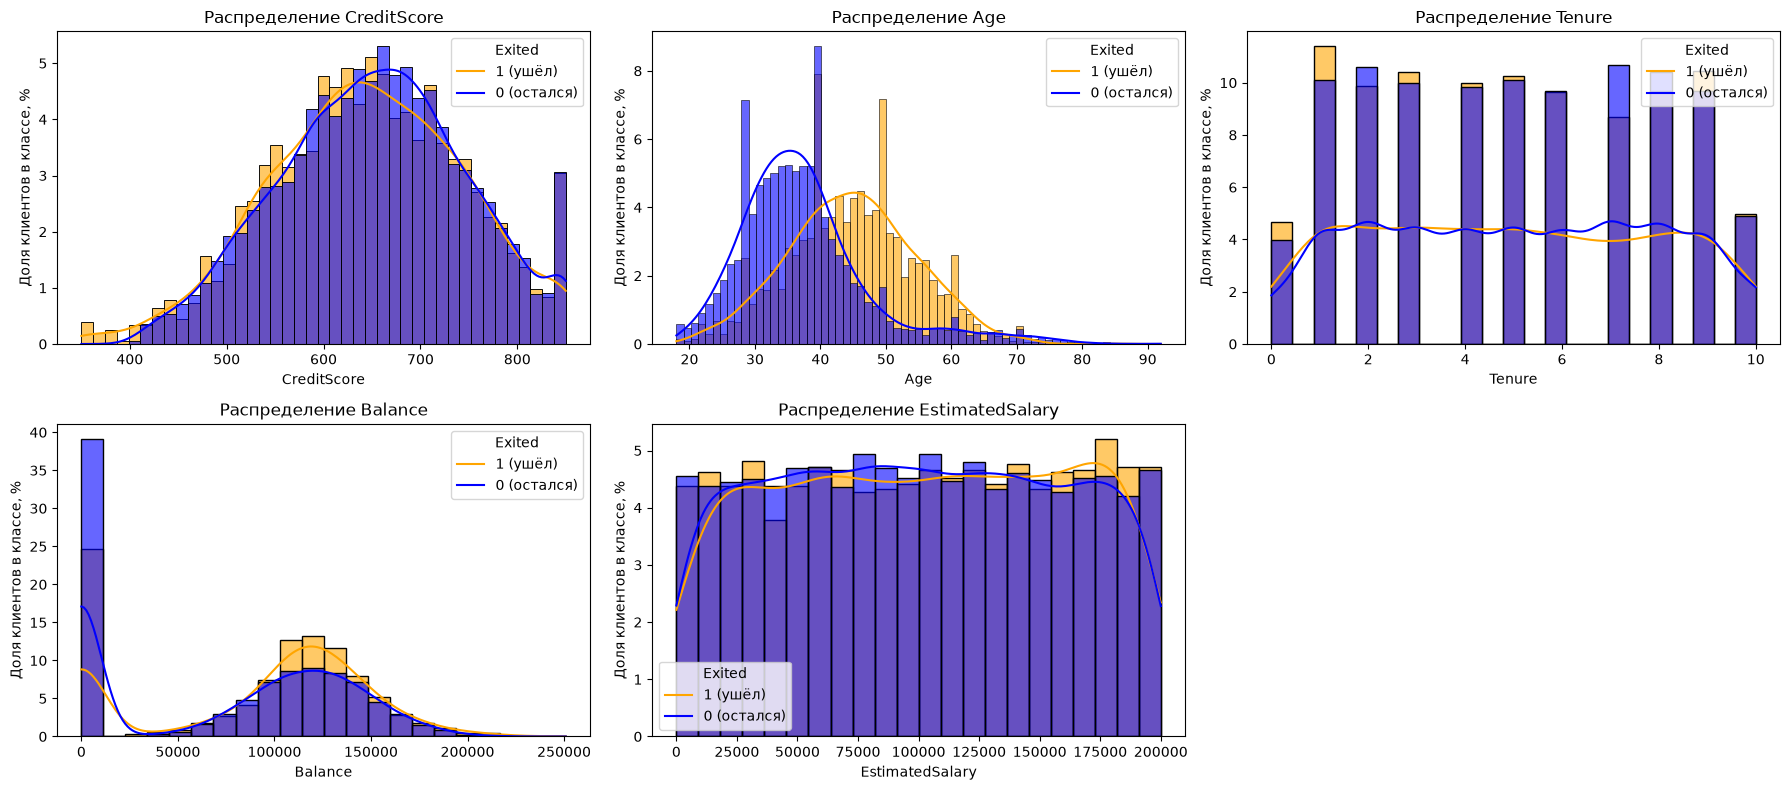

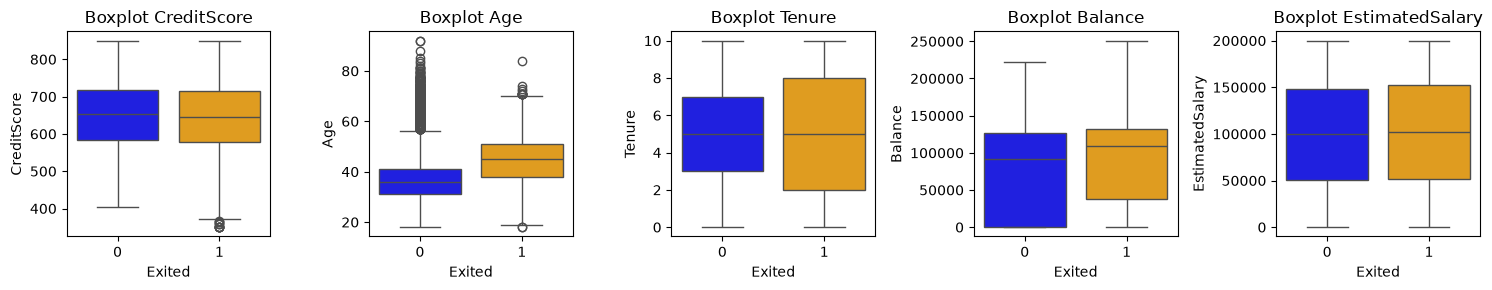

In [246]:
# --- Непрерывные признаки \ с процентом от класса

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    sns.histplot(
        data=df, 
        x=col, 
        hue='Exited', 
        kde=True,
        stat='percent',          #  показывает процент от класса
        common_norm=False,       #  каждый класс нормируется отдельно
        palette={0: 'blue', 1: 'orange'},
        alpha=0.6,
        ax=ax
    )
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Доля клиентов в классе, %')
    ax.legend(title='Exited', labels=['1 (ушёл)','0 (остался)'])

# Убираем пустой график (если есть)
if len(num_cols) < len(axes):
    for i in range(len(num_cols), len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


# 2. Boxplot (ящики с усами) для каждой переменной (по классам)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    # Используем hue для задания цвета по классам, legend=True (можно оставить)
    sns.boxplot(data=df, x='Exited', y=col, hue='Exited', 
                palette={0: 'blue', 1: 'orange'}, 
                legend=False, ax=ax)  # legend=False убирает дублирующую легенду
    ax.set_title(f'Boxplot {col}')
    ax.set_xlabel('Exited')


plt.tight_layout()
plt.show()

## Распределения и графики

**1. CreditScore**
- Разницы между группами почти нет — кредитный рейтинг не является определяющим фактором оттока.

**2. Age**
- Распределение колоколообразное, но с заметным смещением.
- Пик плотности у ушедших приходится на 45–50 лет, у оставшихся — на 35–40.
- Ушедшие клиенты сдвинуты вправо (старше) — медиана 45 против 36 у оставшихся.

**3. Tenure**
- Разницы между группами практически нет — стаж в банке не влияет на отток.

**4. Balance**
-  Распределение имеет две особенности:
  - **Пик в нуле**: доля клиентов с нулевым балансом среди оставшихся значительно выше, чем среди ушедших.
  - **Основная масса** имеет баланс в диапазоне 50–150 тыс. с пиком около 100 тыс.
- У ушедших медиана баланса выше (109 тыс. против 92 тыс.), что может указывать на то, что клиенты с крупными суммами на счетах более склонны к уходу (возможно, они переходят в другие банки с более выгодными условиями).

**5. EstimatedSalary**
- Разницы между группами практически нет — вероятно зарплата будет слабо влиять на отток.

----

Зарплата в отличие от баланса не влияет на отток. При этом у ушедших клиентов по сравнению с оставшимися выше как средний возраст, так и баланс. Можно сделать предположение, что ушедшие клиенты это в основном люди 40-50 лет, стремящиеся к накоплению средств на счёте.  

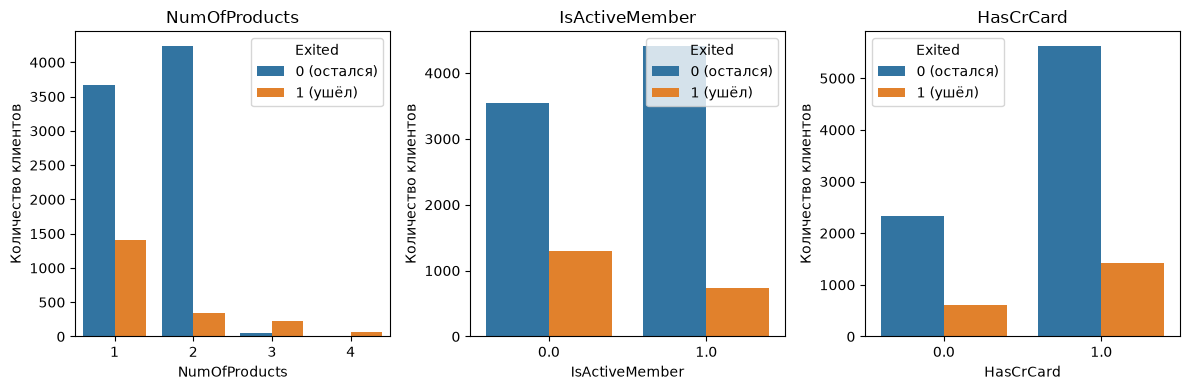

In [247]:
# Создаём отдельные графики для дискретных признаков
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# NumOfProducts
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[0])
axes[0].set_title('NumOfProducts')
axes[0].set_ylabel('Количество клиентов')
axes[0].legend(title='Exited', labels=['0 (остался)', '1 (ушёл)'])

# IsActiveMember
sns.countplot(data=df, x='IsActiveMember', hue='Exited', ax=axes[1])
axes[1].set_title('IsActiveMember')
axes[1].set_ylabel('Количество клиентов')
axes[1].legend(title='Exited', labels=['0 (остался)', '1 (ушёл)'])

# HasCrCard
sns.countplot(data=df, x='HasCrCard', hue='Exited', ax=axes[2])
axes[2].set_title('HasCrCard')
axes[2].set_ylabel('Количество клиентов')
axes[2].legend(title='Exited', labels=['0 (остался)', '1 (ушёл)'])

plt.tight_layout()
plt.show()

**6. NumOfProducts**
- У оставшихся доминирует 1 или 2 продукта , у ушедших — 1, 3 и 4 продукта.
- У оставшихся выше доля клиентов с 2 продуктами.
- Клиенты с 3–4 продуктами встречаются редко, но среди ушедших их чуть больше.

(Возможно среди ушедших клиентов есть группа тех кто резко переходит в другой банк и группа клиентов стремящиеся к лучшим условия обслуживания. Однако для второй группы даже большее количество придуктов банка не удовлетворяет их ожидания.)

**7. IsActiveMember**
- Активные участники программы реже уходят: среди оставшихся 55% активны, среди ушедших — только 36%.

**8. HasCrCard**
- Около 70% клиентов имеют кредитную карту в обеих группах.
- Разница незначительна, поэтому этот признак вряд ли будет сильным предиктором.

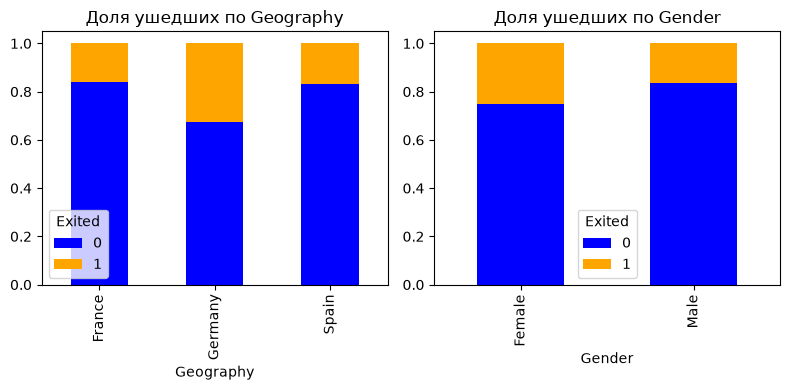

In [248]:
# Пример для категориальных переменных
cat_cols = ['Geography', 'Gender']
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for idx, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Exited'], normalize='index').plot(kind='bar', 
                                                                 stacked=True, 
                                                                 ax=axes[idx], 
                                                                 color=['blue', 'orange'])
    axes[idx].set_title(f'Доля ушедших по {col}')
    axes[idx].legend(title='Exited')
plt.tight_layout()
plt.show()

**9. Geography**
- Очевидно доля ушедших клиентов в Германии раза в 2 (визуально) больше чем во Франции и Испании. Значима ли эта разница покажет дальнейший анализ. 

**10. Gender**
- Доля ушедших клиентов среди женщин больше, чем среди мужчим.

### __Корреляционный анализ и проверка мультиколлинеарности__

Для числовых признаков мы рассчитали непараметрическую корреляцию Спирмена, так как распределения не являются нормальными.

In [249]:
from scipy.stats import spearmanr

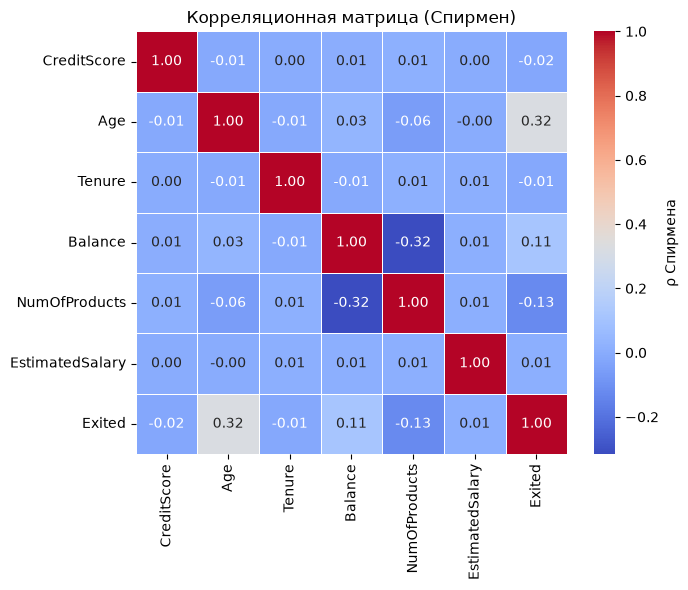

In [250]:
# Список числовых признаков (включая целевую переменную)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']

# Расчёт корреляции Спирмена
corr_spearman = df[num_cols].corr(method='spearman')
# display(corr_spearman.round(3))

# Тепловая карта
plt.figure(figsize=(7, 6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'ρ Спирмена'})
plt.title('Корреляционная матрица (Спирмен)')
plt.tight_layout()
plt.show()

In [251]:
features = ['CreditScore',  'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
# Сбор p-values и коэффициентов
results = []
for col1 in features:
    for col2 in features:
        rho, p = spearmanr(df[col1], df[col2])
        results.append({'Признак_1': col1,'Признак_2': col2,  'r (Спирмен)': round(rho, 3), 'p-value': round(p, 4)})

p_df = pd.DataFrame(results)

print("\n \t\tЗначимые Корреляции и p-values ")
display(p_df[(p_df['p-value']<0.05)&(p_df['r (Спирмен)']!=1)].sort_values(by='r (Спирмен)'))


 		Значимые Корреляции и p-values 


,Признак_1,Признак_2,r (Спирмен),p-value
25,Balance,NumOfProducts,-0.317,0.0000
31,NumOfProducts,Balance,-0.317,0.0000
34,NumOfProducts,Exited,-0.126,0.0000
46,Exited,NumOfProducts,-0.126,0.0000
29,NumOfProducts,Age,-0.059,0.0000
11,Age,NumOfProducts,-0.059,0.0000
42,Exited,CreditScore,-0.023,0.0194
6,CreditScore,Exited,-0.023,0.0194
10,Age,Balance,0.034,0.0008
22,Balance,Age,0.034,0.0008


**Корреляция Спирмена с целевой переменной (Exited)**
	
Максимальное значение корреляции с целевой переменной Exited составляет 0.324 (для признака Age). __Все выявленные статистически значимые связи являются слабыми__ или, в лучшем случае, находятся на нижней границе умеренных. Это означает, что каждый отдельный признак в отдельности не является сильным предиктором оттока (по крайней мере в линейном смысле). Однако их совокупное влияние по итогам моделей машинного обучения может давать хороший эффект.

- __Age__	- Значимая связь.	Наиболее сильный предиктор (из всех слабых связей). С возрастом риск оттока растёт. 

- __Balance__	- Значимая связь.	Слабая положительная связь. Чем выше баланс, тем выше риск. Однако стоит учитывать, что у многих клиентов баланс = 0. 

- __NumOfProducts__	- Значимая связь.	Слабая отрицательная. Чем больше продуктов использует клиент, тем ниже риск оттока. Лояльность растёт с числом продуктов.

- __CreditScore__	- Значимая связь.	Статистически значима, но очень слабая. Практического влияния нет.

- Tenure	-	 Не значимо (Не попала в список по критерию p-value<0.05).	Продолжительность сотрудничества с банком не влияет на отток.

- EstimatedSalary	-	 Не значимо. (Не попала в список по критерию p-value<0.05)	Зарплата не связана с оттоком.

 
Другие значимые корреляций (p < 0.05)
Из таблицы p-values видны следующие статистически значимые связи (не только с целевой переменной, но и между признаками):

Balance	- NumOfProducts :	(r=−0.317)	Слабая отрицательная связь (но одна из наиболее сильных). Клиенты с высоким балансом используют меньше продуктов.


**Возможные причины выявленных связей**:

- Возраст — пожилые клиенты чаще уходят: они могут выходить на пенсию, менять банк или закрывать счета.

- Balance — клиенты с большими накоплениями могут быть более мобильны и переходить в банки с более выгодными условиями.

- NumOfProducts — чем больше продуктов у клиента (кредитная карта, депозит, ипотека), тем выше его «привязанность» к банку.

### **VIF (Variance Inflation Factor)**

VIF (коэффициент инфляции дисперсии) — это метрика, которая показывает, насколько сильно один признак коррелирует с другими признаками в анализе. Он используется для диагностики мультиколлинеарности — ситуации, когда признаки "дублируют" информацию друг друга.

- По результатам корреляционного анализа не было найдено сильных связей между независимыми признаками, поэтому нет оснований полагать что обнаружится мультиколлинеарность

Интерпретация VIF:

- VIF = 1 — признак не коррелирует с другими (идеально).
- VIF = 1–5 — умеренная корреляция, обычно допустимо.
- VIF > 5 — высокая мультиколлинеарность, стоит задуматься об удалении или объединении признаков.

In [252]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
# --------  VIF 

X = df[num_cols[:-1]]  # все, кроме Exited
# Добавляем константу для расчёта VIF
X_const = add_constant(X)

# Расчёт VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]


display(vif_data.round(3))

,Variable,VIF
0,const,1.000
1,CreditScore,1.000
2,Age,1.002
3,Tenure,1.000
4,Balance,1.103
5,NumOfProducts,1.103
6,EstimatedSalary,1.001


**Интерпретация:**

- Все VIF близки к 1.0,  мультиколлинеарность отсутствует.

- Самые высокие значения — у Balance и NumOfProducts (1.1), что ожидаемо, так как между ними есть слабая отрицательная корреляция (−0.317). Однако значение 1.1 не создаздаст проблем.

**Вывод:** мультиколлинеарность __отсутствует__. Можно включить все числовые признаки в модель без дополнительных преобразований.

### **Анализ категориальных признаков**

Для оценки связи категориальных переменных с целевой переменной (`Exited`) используем **таблицы сопряжённости** и проверим **хи-квадрат тест**. Это позволяет определить, есть ли статистически значимые различия в долях ушедших клиентов между категориями.

In [253]:
from scipy.stats import chi2_contingency

In [254]:
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

print(" \t\tТаблицы сопряжённости и хи-квадрат тест ")
for col in cat_cols:
    # Абсолютные частоты с итогами
    cross = pd.crosstab(df[col], df['Exited'], margins=True)
    # Доля ушедших (Exited=1) по каждой категории (в %)
    share = pd.crosstab(df[col], df['Exited'], normalize='index').round(3) * 100
    
    chi2, p, dof, expected = chi2_contingency(pd.crosstab(df[col], df['Exited']))
    
    print("\n",col)
    display(cross)
    print("\nДоля ушедших (%) по категориям:")
    display(share[1]) # столбец 1 = Exited = 1
    print(f"\nХи-квадрат = {chi2:.2f}, p-value = {p:.4f}")

 		Таблицы сопряжённости и хи-квадрат тест 

 Geography


Exited,0,1,All
Geography,,,
France,4200,810,5010
Germany,1695,813,2508
Spain,2063,413,2476
All,7958,2036,9994



Доля ушедших (%) по категориям:


Geography
France     16.2
Germany    32.4
Spain      16.7
Name: 1, dtype: float64


Хи-квадрат = 299.67, p-value = 0.0000

 Gender


...


Хи-квадрат = 0.48, p-value = 0.4876

 IsActiveMember


Exited,0,1,All
IsActiveMember,,,
0.0,3546,1301,4847
1.0,4412,735,5147
All,7958,2036,9994



Доля ушедших (%) по категориям:


IsActiveMember
0.0    26.8
1.0    14.3
Name: 1, dtype: float64


Хи-квадрат = 242.02, p-value = 0.0000


#### Результаты хи-квадрат теста

| Признак | p-value | Значимость | Интерпретация |
|---------|---------|------------|---------------|
| **Geography** | **0.0** |  Значим | Доля ушедших сильно различается по странам. Германия — зона повышенного риска. |
| **Gender** | **0.0** |  Значим | Женщины уходят чаще мужчин. |
| **IsActiveMember** |  **0.0** |  Значим | Неактивные участники программ уходят значительно чаще. |
| **HasCrCard** |  0.48 |  Не значим | Наличие кредитной карты не влияет на отток. |

#### Анализ долей ушедших

Из таблиц сопряжённости можно выделить ключевые различия:

- **Geography:**
  - Германия: **32.4%** ушедших (813 из 2508)
  - Испания: **16.7%** (413 из 2476)
  - Франция: **16.2%** (810 из 5010)
  - **Вывод:** клиенты из Германии уходят почти в 2 раза чаще, чем из других стран.

- **Gender:**
  - Женщины: **25.1%** ушедших (1139 из 4541)
  - Мужчины: **16.5%** (897 из 5453)
  - **Вывод:** женщины более склонны к оттоку.

- **IsActiveMember:**
  - Неактивные: **26.8%** ушедших (1301 из 4847)
  - Активные: **14.3%** (735 из 5147)
  - **Вывод:** активные участники программ лояльности уходят в 2 раза реже.

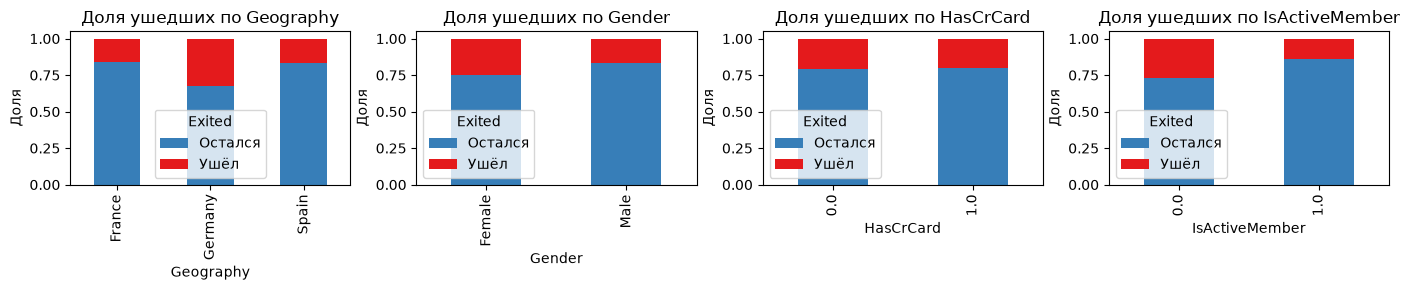

In [255]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Exited'], normalize='index').plot(kind='bar', 
                                                                stacked=True, 
                                                                ax=axes[idx],
                                                                color=['#377eb8', '#e41a1c'])
    axes[idx].set_title(f'Доля ушедших по {col}')
    axes[idx].legend(title='Exited', labels=['Остался', 'Ушёл'])
    axes[idx].set_ylabel('Доля')

plt.tight_layout()
plt.show()

In [256]:
from scipy.stats import mannwhitneyu

In [257]:
print("\t\t Тест Манна-Уитни для числовых признаков\n ")
for col in num_cols[:-1]:  # все кроме Exited
    group0 = df[df['Exited'] == 0][col]
    group1 = df[df['Exited'] == 1][col]
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    print(f"{col}: p-value = {p:.4f} {'      (значимо)' if p < 0.05 else '  (не значимо)'}")

		 Тест Манна-Уитни для числовых признаков
 
CreditScore: p-value = 0.0194       (значимо)
Age: p-value = 0.0000       (значимо)
Tenure: p-value = 0.1631   (не значимо)
Balance: p-value = 0.0000       (значимо)
NumOfProducts: p-value = 0.0000       (значимо)
EstimatedSalary: p-value = 0.2336   (не значимо)


### Сравнение числовых признаков между группами (тест Манна-Уитни)

Для числовых признаков мы использовали **непараметрический тест Манна-Уитни**, который проверяет, есть ли между 2мя группами статистически значимые различия по уровню какого-либо признака ( в нашем случа в группах ушедших и оставшихся клиентов).

#### Результаты теста

- **CreditScore** - Различие есть, но очень слабое. Практически не влияет.
- **Age** - Возраст значимо различается (ушедшие клиенты старше).
- **Tenure** - Стаж в банке не различается между группами.
- **Balance** - Баланс значимо различается (ушедшие имеют более высокий баланс ).
- **NumOfProducts** - Число продуктов различается (ушедшие используют меньше продуктов).
- **EstimatedSalary** - Зарплата не различается между группами.

#### Вывод по числовым признакам

В модели будут наиболее значимы: `Age`  `Balance` `NumOfProducts` 

Признаки `Tenure` и `EstimatedSalary` можно исключить из модели или оставить, но врядли они окажут сильное влияние. `CreditScore` статистически значим, но его влияние очень слабое — можно оставить.

---

### Общий вывод 

1. **Наиболее сильные предикторы оттока** (по совокупности тестов):
   - **Age** (числовой, корреляция 0.324)
   - **IsActiveMember** (категориальный, неактивные → выше риск)
   - **Geography** (категориальный, Германия → выше риск)
   - **Gender** (категориальный, женщины → выше риск)
   - **NumOfProducts** (числовой, меньше продуктов → выше риск)
   - **Balance** (числовой, высокий баланс → выше риск, но с оговорками)

2. **Признаки, которые можно исключить**:
   - `HasCrCard` — не значим
   - `Tenure` — не значим
   - `EstimatedSalary` — не значим
   - `CreditScore` — значим, но влияние крайне слабое (можно оставить)

In [258]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### **Построение базовых моделей классификации (Baseline) на несбалансированных данных**

#### 1. Предобработка данных

Перед обучением моделей  выполняем стандартную предобработку:

- **Разделение данных** на обучающую (60%), валидационную (20%) и тестовую (20%) выборки с сохранением пропорций классов (`stratify`).  
  Это позволит:
  - Использовать валидационную выборку для ранней остановки в XGBoost.
  - Оценить качество на тестовой выборке, не участвовавшей в подборе гиперпараметров.

- **Стандартизация числовых признаков** (`StandardScaler`) — обязательна для логистической регрессии, так как она чувствительна к масштабу признаков. Для XGBoost применим  трансформацию для единообразия.

- **One-Hot кодирование категориальных признаков** (`Geography`, `Gender`, `IsActiveMember`) с удалением первой категории (`drop='first'`), чтобы избежать мультиколлинеарности, возникающей  между закодированными столбцами при One-Hot кодировании.

In [259]:
# train val test

num_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts']
cat_cols = ['Geography', 'Gender', 'IsActiveMember']
X = df[num_cols+cat_cols]
y = df['Exited']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Проверяем размеры
print(f"Train: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

def print_class_distribution(y, name):
    n = len(y)
    ones = sum(y)
    zeros = n - ones
    print(f"{name}:")
    print(f"  Всего: {n}")
    print(f"  Класс 0 (остались): {zeros} ({zeros/n*100:.2f}%)")
    print(f"  Класс 1 (ушли):   {ones} ({ones/n*100:.2f}%)")
    print()

print_class_distribution(y_train, "Train")
print_class_distribution(y_val, "Validation")
print_class_distribution(y_test, "Test")

#  Стандартизация и кодирования 
preprocessor_tree = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# 3. Трансформируем обучающие и валидационные данные
X_train_tree = preprocessor_tree.fit_transform(X_train)
X_val_tree = preprocessor_tree.transform(X_val)
X_test_tree = preprocessor_tree.transform(X_test)

Train: 5996 samples
Validation: 1999 samples
Test: 1999 samples
Train:
  Всего: 5996
  Класс 0 (остались): 4774 (79.62%)
  Класс 1 (ушли):   1222 (20.38%)

Validation:
  Всего: 1999
  Класс 0 (остались): 1592 (79.64%)
  Класс 1 (ушли):   407 (20.36%)

Test:
  Всего: 1999
  Класс 0 (остались): 1592 (79.64%)
  Класс 1 (ушли):   407 (20.36%)



## __Базовые модели: характеристики и сравнение__

#### __XGBoost (градиентный бустинг на деревьях решений)__

__Краткая характеристика:__

XGBoost — это ансамблевый метод, который последовательно строит деревья решений, каждое из которых исправляет ошибки предыдущих. Использует градиентный спуск для минимизации функции потерь.

__Сильные стороны:__

- Автоматически учитывает нелинейные зависимости и взаимодействия признаков (без ручного конструирования новых доп-признаков).
- Устойчив к выбросам и пропускам (если правильно настроить параметры).
- Регуляризация (L1/L2) помогает бороться с переобучением.
- Поддерживает раннюю остановку, взвешивание классов и работу с категориальными признаками.

__Слабые стороны:__

- Менее интерпретируем, чем линейная модель (хотя важность признаков и SHAP помогают).
- Требует больше времени на обучение и настройку гиперпараметров.
- При малом объёме данных может переобучаться.

In [260]:
import xgboost as xgb

model = xgb.XGBClassifier(
    objective='binary:logistic', # Функция потерь для бинарной классификации
    n_estimators=200,           # Количество деревьев (итераций бустинга)
    max_depth=4,                 # Максимальная глубина каждого дерева
    learning_rate=0.1,
    subsample=0.8,              #Доля обучающих наблюдений, используемых для каждого дерева
    colsample_bytree=0.8,         # Доля признаков, используемых для каждого дерева
    random_state=42,
    eval_metric='logloss',      # Метрика для оценки на валидации
    early_stopping_rounds=10    # Позволяет остановить обучение во время валидации, 
                                # если оценочный показатель перестаёт улучшаться.
)

model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=False  # подробности обучения
)
print(f"Лучшее число деревьев: {model.best_iteration}")

Лучшее число деревьев: 88


In [261]:
y_pred = model.predict(X_test_tree)
y_proba = model.predict_proba(X_test_tree)[:, 1]

print("\t\t XGBoost с early stopping ")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.3f}")

		 XGBoost с early stopping 
Accuracy: 0.861
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1592
           1       0.75      0.48      0.59       407

    accuracy                           0.86      1999
   macro avg       0.81      0.72      0.75      1999
weighted avg       0.85      0.86      0.85      1999

Confusion Matrix:
[[1526   66]
 [ 211  196]]
ROC-AUC: 0.866
PR-AUC: 0.701


In [262]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

### __Логистическая регрессия__

__Краткая характеристика:__

Логистическая регрессия — линейный метод классификации. Она оценивает вероятность события (принадлежности к классу) через логистическую функцию от взвешенной суммы признаков.

__Сильные стороны:__

- Интерпретируемость — коэффициенты показывают направление и силу влияния признаков.
- Быстрое обучение и предсказание.
- Не требует настройки большого числа гиперпараметров.
- Работает хорошо, когда зависимость между признаками и целевой переменной близка к линейной.

__Слабые стороны:__

- Не улавливает нелинейные зависимости.
- Требует ручного добавления взаимодействий между признаками.
- Чувствительна к выбросам и мультиколлинеарности (в нашем случае VIF был низким).
- При сильном дисбалансе классов может давать низкий recall по миноритарному классу.

In [263]:
# Обучение LogisticRegression
lr_model = LogisticRegression(
    C=1.0,                  # обратная сила регуляризации (по умолчанию)
    solver='lbfgs',         # оптимизатор, хорошо работает для небольших данных
    max_iter=2000,          # увеличенное число итераций для гарантированной сходимости
    random_state=42
)

lr_model.fit(X_train_tree, y_train)

# Предсказания и оценка
y_pred_lr = lr_model.predict(X_test_tree)
y_proba_lr = lr_model.predict_proba(X_test_tree)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_lr):.3f}")

=== Logistic Regression ===
Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1592
           1       0.56      0.20      0.29       407

    accuracy                           0.80      1999
   macro avg       0.69      0.58      0.59      1999
weighted avg       0.77      0.80      0.77      1999

Confusion Matrix:
[[1529   63]
 [ 327   80]]
ROC-AUC: 0.769
PR-AUC: 0.463


####  **Результаты базовых моделей**

| Модель | Accuracy | ROC-AUC | PR-AUC | Recall (класс 1) | Precision (класс 1) | F1 (класс 1) |
|--------|----------|---------|--------|------------------|---------------------|--------------|
| **Logistic Regression** | 0.805 | 0.769 | 0.463 | 0.20 | 0.56 | 0.29 |
| **XGBoost** | **0.861** | **0.866** | **0.701** | **0.48** | **0.75** | **0.59** |

#### 3. Интерпретация

- **XGBoost** значительно превосходит логистическую регрессию по всем метрикам, особенно по **recall** (0.48 против 0.20). Это означает, что бустинг находит почти половину уходящих клиентов, тогда как логистическая регрессия — лишь каждого пятого.
- Однако даже XGBoost имеет низкий recall по классу «отток» (0.48) — это ожидаемо из-за дисбаланса классов (20% ушедших против 80% оставшихся).
- **PR-AUC** для логистической регрессии очень низкая (0.463), что говорит о том, что модель плохо разделяет классы по вероятностям. Для XGBoost PR-AUC = 0.701 — это приемлемый результат, но всё ещё далёкий от идеала (1.0).
####  Недостатки базовых моделей

- **Дисбаланс классов** остаётся главной проблемой — модели хуже обучаются на миноритарном классе.
- **Recall по классу «отток»** недостаточен для бизнес-задач. Если мы хотим предотвратить уход клиентов, мы должны уметь выявлять как можно больше потенциально уходящих клиентов.
- **Логистическая регрессия** даёт слишком низкий recall (0.20) — она практически не видит отток.

Эти результаты служат **точкой отсчёта** для улучшения моделей с помощью методов борьбы с дисбалансом (SMOTE, взвешивание классов, настройка порога).
#### __Важность признаков__

Для интерпретации моделей мы можем оценить вклад каждого признака:

- **Для логистической регрессии** — модуль коэффициента (вес) показывает силу влияния признака на вероятность оттока. Так как признаки стандартизированы, коэффициенты сопоставимы.

In [264]:
# Получаем имена признаков после трансформации
feature_names = preprocessor_tree.get_feature_names_out()

# Коэффициенты логистической регрессии (уже есть lr_model)
# coefs = lr_model.coef_[0]   # массив весов для каждого признака
coefs = lr_model.coef_[0]
importance_lr = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print("\n\t Важность признаков (Logistic Regression) ")
print(importance_lr)
# feature_importances_ по умолчанию использует 'weight' (количество раз, когда признак использовался для разделения)
# Более информативно использовать 'gain' — улучшение качества при разделении.
importance_xgb = pd.DataFrame({
    'feature': feature_names,
    'gain': model.feature_importances_   # уже вычислено во время обучения
}).sort_values('gain', ascending=False)

print("\n\t Важность признаков (XGBoost) ")
print(importance_xgb)


	 Важность признаков (Logistic Regression) 
                   feature      coef  abs_coef
7  cat__IsActiveMember_1.0 -1.036583  1.036583
1                 num__Age  0.757293  0.757293
4   cat__Geography_Germany  0.748012  0.748012
6         cat__Gender_Male -0.560085  0.560085
2             num__Balance  0.191538  0.191538
0         num__CreditScore -0.072233  0.072233
3       num__NumOfProducts -0.061279  0.061279
5     cat__Geography_Spain  0.045654  0.045654

	 Важность признаков (XGBoost) 
                   feature      gain
3       num__NumOfProducts  0.269064
1                 num__Age  0.200106
7  cat__IsActiveMember_1.0  0.194325
4   cat__Geography_Germany  0.128533
6         cat__Gender_Male  0.065550
2             num__Balance  0.063522
0         num__CreditScore  0.039510
5     cat__Geography_Spain  0.039389


### Сравнение важности признаков в двух моделях

После обучения базовых моделей мы проанализировали, какие признаки сильнее всего влияют на прогноз оттока. Результаты представлены в двух таблицах: для логистической регрессии — коэффициенты (со знаком), для XGBoost — метрика `gain` (без знака).

---

#### Логистическая регрессия (коэффициенты)

- **IsActiveMember_1.0**: Активные участники имеют значительно меньший риск оттока. Это самый сильный фактор. 
- **Age**: С возрастом риск оттока растёт. 
- **Geography_Germany**:  Клиенты из Германии уходят чаще, чем из Франции (базовая категория). 
- **Gender_Male**:  Мужчины уходят реже, чем женщины. 
- **Balance**: Слабый положительный вклад — высокий баланс немного повышает риск. 
- CreditScore: Практически не влияет. 
- NumOfProducts: Чуть больше продуктов — чуть ниже риск. 
- Geography_Spain: Незначительное отличие от Франции. 

**Вывод:** Логистическая регрессия выделяет четыре ключевых фактора: **неактивность** (самый сильный), **возраст**, **проживание в Германии** и **пол**. Остальные признаки дают незначительный вклад.

---

#### XGBoost (важность по `gain`)

- **NumOfProducts**: Самый важный признак в XGBoost. Это означает, что разделение по числу продуктов даёт наибольшее улучшение качества на деревьях. 
- **Age**: Второй по важности. Подтверждает выводы логистической регрессии. 
- **IsActiveMember_1.0**: Третий по важности. Почти так же важен, как и Age. 
- **Geography_Germany**: Четвёртый по важности. 
- **Gender_Male**: Слабый вклад. 
- **Balance**: Слабый вклад. 
- CreditScore: Слабый вклад. 
- Geography_Spain: Слабый вклад. 

**Вывод:** XGBoost также выделяет те же ключевые факторы, но порядок важности отличается. `NumOfProducts` становится самым важным, что может быть связано с тем, что в бустинге этот признак хорошо работает в комбинации с другими (например, клиенты с 1 продуктом и высоким возрастом имеют высокий риск). Тем не менее, все четыре ключевых признака совпадают с логистической регрессией.

---

#### важность признаков в двух моделях __вывод:__

Несмотря на разницу в методах, **обе модели выделяют один и тот же набор ключевых факторов**:
- Неактивность
- Возраст
- Страна (Германия)
- Пол
### __Общий вывод по EDA и базовым моделям и предположения о поведении клиентов__

__Гипотеза о скрытых группах__

На основе наблюдаемых данных предположительно можно выделить как минимум 3 скрытые группы ушедших клиентов:

|Группа |	Признаки |	Почему уходят |
|-------|------------|----------------|
|Накопители|	Возраст > 40, высокий Balance, низкая активность|	Копят деньги, возможно, переходят в банки с более выгодными депозитами.|
| «Компенсаторы»|	2+ продуктов, но всё равно уходят|	Пытались найти подходящий продукт, но не нашли — уходят разочарованными.|
|Слабоактивные|	Нулевой Balance, 1 продукт, неактивные|	Случайные клиенты, которые быстро уходят.|

__Почему бустинг даёт лучшее качество, чем регрессия?__

Логистическая регрессия строит глобальную линейную границу, разделяя классы одной прямой (в многомерном пространстве). Однако в наших данных структура оттока нелинейна (слабая корреляция), также возможно наличие скрытых подгрупп. 
Бустинг «видит» эти группы естественным образом: деревья автоматически находят разбиения, которые выделяют такие паттерны. 

In [265]:
# Объединяем все данные после предобработки (train+val+test)
X_all_tree = preprocessor_tree.transform(X)   # X — исходные признаки без целевой
y_all = df['Exited']

### Проверка кластерной структуры данных

Было выявлено, что связь признаков с целевой переменной не является линейной, и сделано предположение что данные могут содержать скрытые подгруппы клиентов. Для проверки этой гипотезы  визуализируем данные в пространстве пониженной размерности с помощью трёх методов: линейного PCA и нелинейных t‑SNE и UMAP.

#### Цель визуализации

- Проверить, образуют ли клиенты естественные кластеры, которые не видны в исходном пространстве.
- Оценить, есть ли кластеры, в которых концентрация ушедших клиентов выше.
- Понять, можно ли использовать кластерную структуру как дополнительный признак для модели.

In [266]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap # pip install umap-learn

#### __Зачем нужна стандартизация для PCA, t-SNE и UMAP__

Методы снижения размерности (PCA, t-SNE, UMAP) работают на основе **расстояний** между точками в исходном пространстве признаков. Если признаки имеют разный масштаб, это приводит к искажению проекции.

**Проблема без стандартизации:**
- `Balance` имеет разброс от 0 до 250 000.
- `NumOfProducts` — от 1 до 4.
- `Age` — от 18 до 92.
- `CreditScore` — от 350 до 850.

В пространстве расстояний доминирует признак с наибольшим разбросом (`Balance`). Его вклад в расстояние в 1000+ раз больше, чем у `NumOfProducts`. Алгоритмы «видят» только `Balance` и игнорируют остальные признаки. На графике это проявляется как **одна вытянутая «спираль»**, отражающая только этот признак.

**Эффект стандартизации:**
- Все признаки приводятся к единому масштабу (среднее = 0, стандартное отклонение = 1).
- Каждый признак вносит **равный вклад** в расстояние.
- На графике проявляется **многомерная структура**: кластеры, разрывы, зоны концентрации.
- Становятся видны **концентрации клиентов оттока**

Размер данных: (9994, 8)
PCA explained variance: 0.478


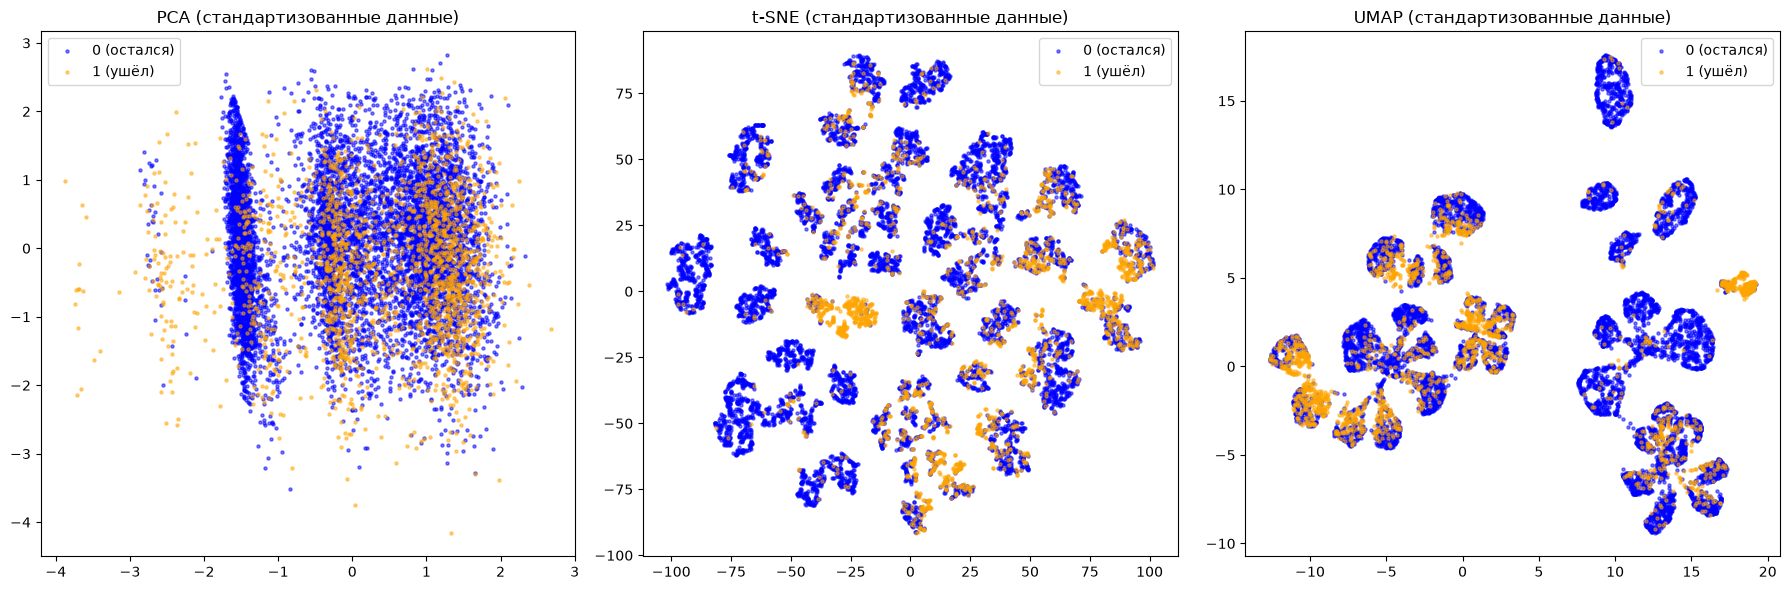

In [267]:
# ----------- One-Hot для категориальных + StandardScaler для числовых
# Категориальные и числовые признаки (без целевой)
cat_cols_vis = ['Geography', 'Gender', 'IsActiveMember']
num_cols_vis = ['CreditScore', 'Age', 'Balance', 'NumOfProducts']

preprocessor_vis = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_vis),
    ('num', StandardScaler(), num_cols_vis)
])

# Применяем к исходным данным X (все клиенты) и y
X_vis_scaled = preprocessor_vis.fit_transform(X)
y_vis = y.values  # целевая переменная
print(f"Размер данных: {X_vis_scaled.shape}")

# ----------- Снижение размерности
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_vis_scaled)

# UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
X_umap = umap_reducer.fit_transform(X_vis_scaled)

# ----------- Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA
axes[0].scatter(X_pca[y_vis==0, 0], X_pca[y_vis==0, 1], c='blue', label='0 (остался)', alpha=0.5, s=5)
axes[0].scatter(X_pca[y_vis==1, 0], X_pca[y_vis==1, 1], c='orange', label='1 (ушёл)', alpha=0.5, s=5)
axes[0].set_title('PCA (стандартизованные данные)')
axes[0].legend()

# t-SNE
axes[1].scatter(X_tsne[y_vis==0, 0], X_tsne[y_vis==0, 1], c='blue', label='0 (остался)', alpha=0.5, s=5)
axes[1].scatter(X_tsne[y_vis==1, 0], X_tsne[y_vis==1, 1], c='orange', label='1 (ушёл)', alpha=0.5, s=5)
axes[1].set_title('t-SNE (стандартизованные данные)')
axes[1].legend()

# UMAP
axes[2].scatter(X_umap[y_vis==0, 0], X_umap[y_vis==0, 1], c='blue', label='0 (остался)', alpha=0.5, s=5)
axes[2].scatter(X_umap[y_vis==1, 0], X_umap[y_vis==1, 1], c='orange', label='1 (ушёл)', alpha=0.5, s=5)
axes[2].set_title('UMAP (стандартизованные данные)')
axes[2].legend()

plt.tight_layout()
plt.show()

#### Результаты

- **PCA** показал несколько вытянутых облаков, но классы распределены по ним практически равномерно. Это согласуется со слабой линейной корреляцией признаков с целевой переменной.

- **t-SNE** и **UMAP** выявили более сложную структуру. На обоих графиках данные разделены на множество компактных облаков («лепестков»), причём:
  - Наблюдения оттока присутствуют почти во всех кластерах, но концентрация неравномерна.
  - Можно выделить **зоны** с повышенной плотностью ушедших:
    - **Почти чистый кластер оттока** — виден на обоих графиках.
    - **Поляризованные облака** — на графиках есть несколько кластеров, где концентрация ушедших сдвинута к краю "облака", а не равномерно перемешана с оставшимися.
    - **«Сердцевина»** — у таких поляризованных облаков есть свой центр притяжения, куда стягиваются наблюдения оттока из этих кластеров.

**Интерпретация:** наличие нескольких зон с повышенной концентрацией оттока подтверждает гипотезу о неоднородности ушедших клиентов. Однако группы не изолированы — их границы размыты.

#### Решение

Хотя структура видна,  **не вводим дополнительную переменную на основе кластеризации**. Причины:

- __Границы между кластерами нечёткие__, и жёсткое присвоение метки может внести шум в модель.
- __XGBoost__ уже __способен__ автоматически __выявлять нелинейные взаимодействия__ и локальные структуры, что подтверждается его высоким качеством (Recall = 0.48 против 0.20 у логистической регрессии).
- **Дополнительная переменная усложнит интерпретацию** без гарантированного прироста качества.

Вместо этого  сосредоточимся на улучшении модели через борьбу с дисбалансом классов и настройку порога классификации. 

---

### __Интерпретация через дерево решений C&RT__

Бустинг может дать хорошее качество, но его сложно интерпретировать. __Для наглядного представления  правил__, приводящих к оттоку, мы обучили дерево решений C&RT (реализация CART в scikit-learn). Гиперпараметры: `max_depth=4`, `min_samples_leaf=50`, `class_weight='balanced'` (для учёта дисбаланса классов).

In [268]:
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

In [269]:
# class_weight='balanced' автоматически учитывает дисбаланс классов
tree_model = DecisionTreeClassifier(
    max_depth=4,               # ограничиваем глубину для читаемости
    min_samples_leaf=50,       # в листе должно быть не менее 50 клиентов
    min_samples_split=100,     # для разбиения узла нужно минимум 100 клиентов
    class_weight='balanced',   # учитываем дисбаланс
    random_state=42,
    criterion='gini'           # критерий Джини — стандарт для CART
)

tree_model.fit(X_train_tree, y_train)

# тест
y_pred_tree = tree_model.predict(X_test_tree)
y_proba_tree = tree_model.predict_proba(X_test_tree)[:, 1]

print("=== Дерево решений C&RT ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.3f}")
print(classification_report(y_test, y_pred_tree))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_tree):.3f}")

=== Дерево решений C&RT ===
Accuracy: 0.738
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1592
           1       0.42      0.75      0.54       407

    accuracy                           0.74      1999
   macro avg       0.67      0.74      0.68      1999
weighted avg       0.82      0.74      0.76      1999

ROC-AUC: 0.812
PR-AUC: 0.556


**Метрики на тестовой выборке:**
| Метрика | Значение |
|---------|----------|
| Accuracy | 0.738 |
| Recall (класс 1) | **0.75** |
| Precision (класс 1) | 0.42 |
| F1 (класс 1) | 0.54 |
| ROC‑AUC | 0.812 |
| PR‑AUC | 0.556 |

Дерево даёт **высокий recall** — находит 75% ушедших клиентов, __но ценой низкой точности__ - 0.42 (много ложных срабатываний). Это ожидаемо для интерпретируемой модели.

---

###  Как читать значения на схеме дерева?

В каждом узле дерева указано:

- **Условие** (например, `Age <= 45`): Правило разбиения. Если истина — идём в левую ветвь, иначе — в правую. 
- **samples = X%**: Доля **всех** обучающих клиентов, дошедших до этого узла. Сумма по всем листьям = 100%. 
- **value = [a, b]**: Взвешенные доли классов внутри узла: `a` — доля «остался», `b` — доля «ушёл». Значения **взвешенные** из-за `class_weight='balanced'`. 
- **class**: Преобладающий класс в узле (по взвешенным значениям). 

 **Важно:** из-за балансировки классов значения `value` **не равны фактическим долям**. Чтобы узнать реальную долю оттока, нужно считать её отдельно на исходных данных. Направление (кто преобладает) сохраняется, а абсолютные числа — завышены для класса «ушёл».

**Как читать путь от корня к листу:**
Каждый путь — это готовое бизнес-правило. Например:
> «Если возраст ≤ 45 **и** число продуктов = 1 **и** клиент из Германии → **Ушёл**».

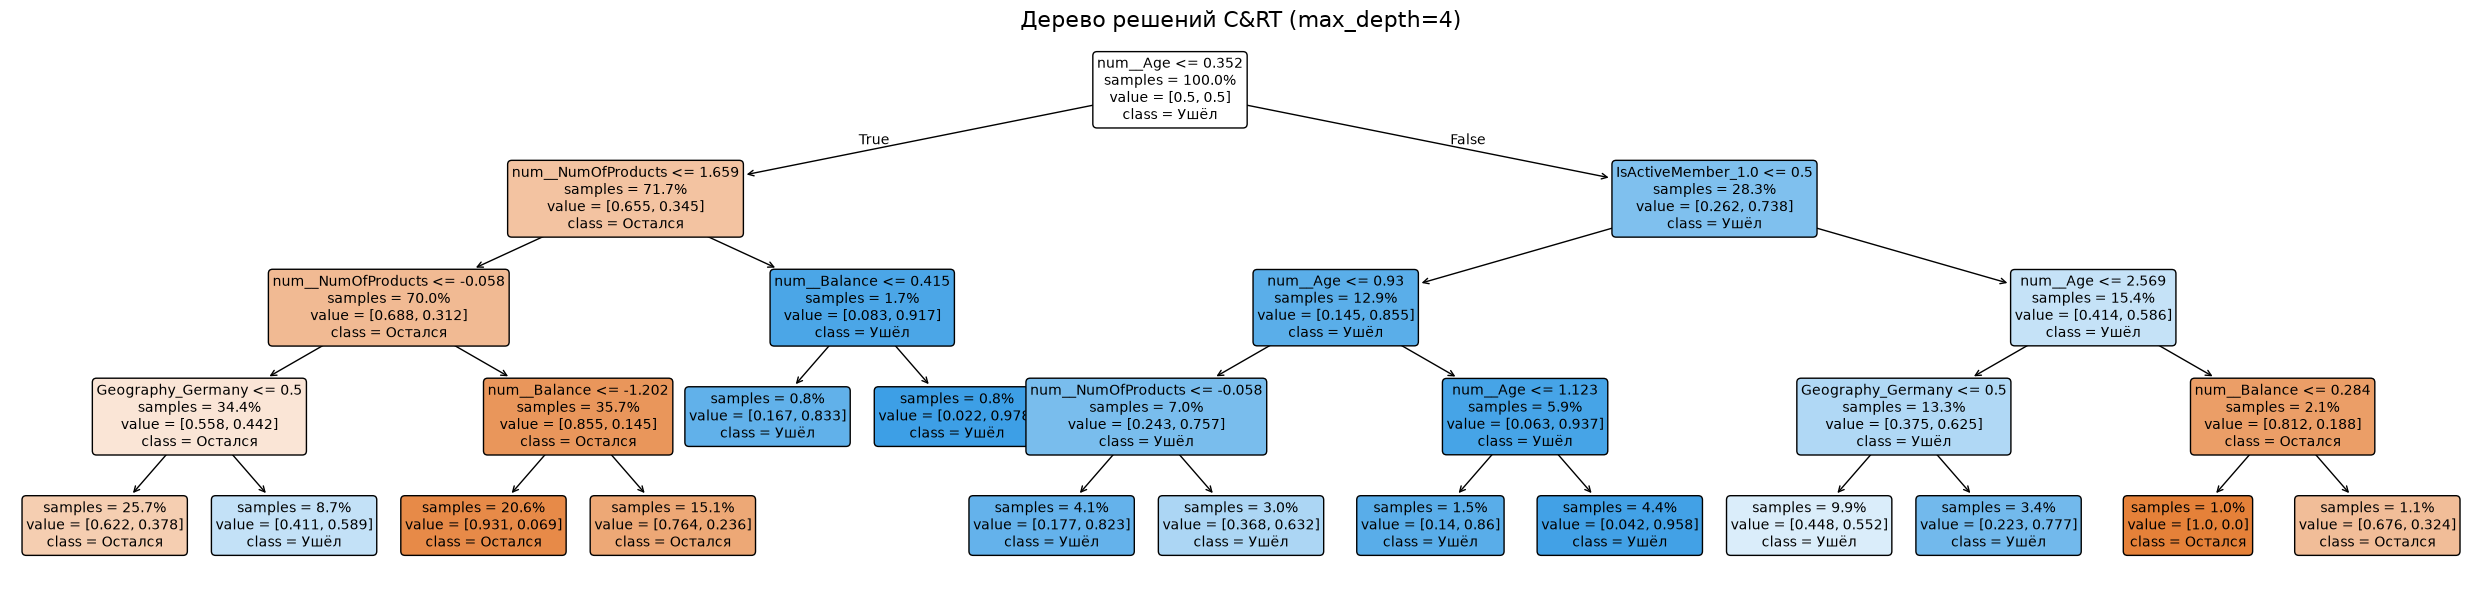

In [270]:
# схема дерева

plt.figure(figsize=(25, 6))
plot_tree(
    tree_model,
    feature_names=[re.split(r'cat__|remainder__', str)[-1] for str in preprocessor_tree.get_feature_names_out()],
    class_names=['Остался', 'Ушёл'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False,      # ← убирает Gini
    proportion=True,    # ← False показывает абсолютные числа в узлах
)
plt.title('Дерево решений C&RT (max_depth=4)', fontsize=16)
plt.tight_layout()
plt.show()

### Структура дерева и бизнес-интерпретация

#### Корень: разбиение по возрасту (Age ≤ 42.5 лет)

| Ветвь | Доля клиентов | Преобладающий класс |
|-------|---------------|---------------------|
| Молодые (≤ 42 года) | 71.7% | Остался |
| Старшие (> 42 лет) | 28.3% | Ушёл |

**Вывод:** возраст — главный фактор, который делит клиентов на две принципиально разные группы.

---

####  __Ветвь 1:__ Молодые клиенты (≤ 42 года)

**1.1. С одним продуктом (NumOfProducts = 1)**

| Правило | Доля клиентов | Прогноз |
|---------|---------------|---------|
| 1 продукт, **не Германия** | 25.7% | Остался |
| 1 продукт, **Германия** | 8.7% | **Ушёл** |

**Вывод:** даже среди молодых клиентов проживание в Германии с одним продуктом  повышен риск оттока.

**1.2. С двумя продуктами (NumOfProducts = 2)**

| Правило | Доля клиентов | Прогноз | Комментарий |
|---------|---------------|---------|-------------|
| 2 продукта, Balance ≤ 1 884 | 20.6% | Остался | Низкий риск (вероятность ухода ~7%) |
| 2 продукта, Balance > 1 884 | 15.1% | Остался | Средний риск (вероятность ухода ~24%) |

**Вывод:** два продукта — защитный фактор, но баланс > 1 884 увеличивает риск в 3 раза, хоть группа и остаётся «лояльной».

**1.3. С тремя и более продуктами (NumOfProducts ≥ 3)**

| Правило | Доля клиентов | Прогноз |
|---------|---------------|---------|
| 3+ продукта, Balance ≤ 102 893 | 0.8% | **Ушёл** |
| 3+ продукта, Balance > 102 893 | 0.8% | **Ушёл** |

**Вывод:** молодые клиенты с 3+ продуктами почти всегда уходят. Возможно, это клиенты, «перегруженные» продуктами, которым банк не смог предложить действительно нужное.

---

#### __Ветвь 2:__ Старшие клиенты (> 42 лет)

Первое разбиение — по активности участия в программах (`IsActiveMember`).

**2.1. Неактивные участники**

| Правило | Доля клиентов | Прогноз |
|---------|---------------|---------|
| 42–48 лет, 1 продукт | 7.0% | **Ушёл** |
| 42–48 лет, 2+ продукта | 5.9% | **Ушёл** |
| 49–50 лет | 5.9% | **Ушёл** |
| **50+ лет** | 4.4% | **Ушёл** (максимальный риск) |

**Вывод:** «старшие + неактивные» — критическая группа. Среди клиентов старше 50 лет, не участвующих в программах, вероятность оттока максимальна.

**2.2. Активные участники**

| Правило | Доля клиентов | Прогноз |
|---------|---------------|---------|
| ≤ 65 лет, **не Германия** | 9.9% | **Ушёл** |
| ≤ 65 лет, **Германия** | 3.4% | **Ушёл** (риск выше в 1.5 раза) |
| 66+ лет, Balance ≤ 94 728 | 1.0% | Остался |
| 66+ лет, Balance > 94 728 | 1.1% | Остался |

**Вывод:**  среди старшего возраста даже активное участие в банковсской программе не спасает от оттока. Единственная «лояльная» группа — клиенты 66+ лет. Причём если у них ещё и низкий баланс, они почти не уходят (вероятно, пенсионеры, которым невыгодно менять банк).

---

###  Ключевые бизнес-правила

| № | Правило | Приоритет |
|---|---------|-----------|
| 1 | **Неактивные клиенты старше 50 лет** — максимальный риск |  Критический |
| 2 | **Молодые клиенты (≤ 42) с 3+ продуктами** — почти все уходят |  Критический |
| 3 | **Клиенты из Германии с 1 продуктом** — высокий риск |  Высокий |
| 4 | **Активные клиенты 42–65 лет из Германии** — риск выше среднего |  Высокий |
| 5 | **Молодые с 2 продуктами и низким балансом** — низкий риск |  Низкий |
| 6 | **Клиенты 66+ лет с низким балансом** — лояльная группа |  Низкий |

---

###  Итоговые выводы

1. **Возраст — главный фактор оттока.** Он делит клиентов на две принципиально разные группы: молодые (в основном остаются) и старшие (в основном уходят).

2. **Комбинации признаков усиливают риск.** Ни один признак в отдельности не определяет отток — важны сочетания:
   - «старший + неактивный» → критический риск,
   - «молодой + 3+ продукта» → почти неизбежный уход,
   - «молодой + 1 продукт + Германия» → 59% уходят.

3. **География (Германия) стабильно повышает риск**

4. **Подтверждены гипотезы о подгруппах:**
   - «Накопители» — старшие, неактивные, с высоким балансом.
   - «Компенсаторы» — с 3+ продуктами, которые не нашли подходящий продукт.
   - «Слабоактивные» — молодые с 1 продуктом.

5. **Дерево даёт готовые правила для отдела удержания.** Каждый путь — это конкретный сценарий, по которому можно запустить целевую кампанию.

---

### ⚠️ __Ограничения дерева__

1. **Низкая precision (0.42).** Модель «перестраховывается» и помечает как уходящих многих клиентов, которые на самом деле остались бы. Это означает, что не все клиенты из «групп риска» действительно уйдут.
2. **Значения риска взвешены.** Из-за `class_weight='balanced'` числа `value` в узлах показывают завышенные доли оттока. Для точной оценки риска нужно считать её отдельно на исходных данных.
3. **Нестабильность.** Деревья решений чувствительны к малым изменениям данных: при повторном обучении правила могут поменяться. Это делает модель менее надёжной, чем ансамбли.
4. **Ограниченный набор признаков.** Дерево использует только 4–5 признаков (`Age`, `NumOfProducts`, `Geography`, `IsActiveMember`, `Balance`). Признаки вроде `CreditScore` и `Gender` оказались незначимыми на такой глубине.
5. **Назначение — интерпретация, не прогноз.** Дерево рекомендуется использовать как **вспомогательный инструмент для объяснения** и формирования бизнес-правил, а не как основную прогнозную модель. Для прогнозирования лучше подходят XGBoost и Random Forest (Recall 0.60–0.66).


## __Создание функций для перебора методов обучения__

Выведем логику обучения и оценки в функции, чтобы легко тестировать разные модели, способы балансировки и гиперпараметры.

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [272]:
# Вспомогательные функции
def print_metrics(y_true, y_pred, y_proba, model_name="Model"):
    """
    Выводит основные метрики качества модели.
    """
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print('='*50)
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(f"\nROC-AUC: {roc_auc_score(y_true, y_proba):.3f}")
    print(f"PR-AUC:  {average_precision_score(y_true, y_proba):.3f}")
    print('='*50)


def run_experiment(X_train, y_train, X_val, y_val, X_test, y_test,
                   model_class, model_params, balance_method=None,
                   fit_params=None, model_name="Model"):
    """
    Обучает модель с возможной балансировкой, оценивает на тестовой выборке.

    Параметры:
    ----------
    model_class     - класс модели (например, xgb.XGBClassifier)
    model_params    - параметры модели (включая взвешивание классов)
    balance_method  - 'smote' или 'undersample' (или None)
    fit_params      - параметры обучения (eval_set, verbose и т.д.)
    model_name      - имя для вывода
    """
    # Балансировка данных (если указана)
    if balance_method is not None:
        if balance_method == 'smote':
            balancer = SMOTE(random_state=42)
        elif balance_method == 'undersample':
            balancer = RandomUnderSampler(random_state=42)
        else:
            raise ValueError("balance_method должен быть 'smote' или 'undersample'")

        X_train_res, y_train_res = balancer.fit_resample(X_train, y_train)
        print(f"После балансировки: {len(X_train_res)} samples")
    else:
        X_train_res, y_train_res = X_train, y_train
        print(f"Без балансировки: {len(X_train_res)} samples")

    # Создание и обучение модели
    model = model_class(**model_params)

    if fit_params is not None:
        model.fit(X_train_res, y_train_res, **fit_params)
    else:
        model.fit(X_train_res, y_train_res)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return model, y_pred, y_proba

# ------  Параметры XGBoost

xgb_base = {
    'objective': 'binary:logistic',
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10,
}

# ------ Словарь экспериментов 

experiments = [
    {
        'name': 'XGBoost (baseline)',
        'model_class': xgb.XGBClassifier,
        'model_params': xgb_base.copy(),
        'balance_method': None,
        'fit_params': {'eval_set': [(X_val_tree, y_val)], 'verbose': False}
    },
    {
        'name': 'XGBoost + scale_pos_weight',
        'model_class': xgb.XGBClassifier,
        'model_params': dict(
            xgb_base,
            scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
        ),
        'balance_method': None,
        'fit_params': {'eval_set': [(X_val_tree, y_val)], 'verbose': False}
    },
    {
        'name': 'XGBoost + SMOTE',
        'model_class': xgb.XGBClassifier,
        'model_params': xgb_base.copy(),
        'balance_method': 'smote',
        'fit_params': {'eval_set': [(X_val_tree, y_val)], 'verbose': False}
    },
    {
        'name': 'XGBoost + Undersampling',
        'model_class': xgb.XGBClassifier,
        'model_params': xgb_base.copy(),
        'balance_method': 'undersample',
        'fit_params': {'eval_set': [(X_val_tree, y_val)], 'verbose': False}
    },
]

In [273]:
# Запуск эксперимента

results = []

for exp in experiments:
    print(f"\n{exp['name']}")

    model, y_pred, y_proba = run_experiment(
        X_train_tree, y_train,
        X_val_tree, y_val,
        X_test_tree, y_test,
        exp['model_class'],
        exp['model_params'],
        balance_method=exp['balance_method'],
        fit_params=exp['fit_params'],
        model_name=exp['name']
    )

    # Сохраняем основные метрики для сравнения
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'model': exp['name'],
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'recall_1': report['1']['recall'],
        'precision_1': report['1']['precision'],
        'f1_1': report['1']['f1-score'],
    })

df_results = pd.DataFrame(results).sort_values('f1_1', ascending=False)
display(df_results.round(3))


XGBoost (baseline)
Без балансировки: 5996 samples

XGBoost + scale_pos_weight
Без балансировки: 5996 samples

XGBoost + SMOTE
После балансировки: 9548 samples

XGBoost + Undersampling
После балансировки: 2444 samples


,model,accuracy,roc_auc,pr_auc,recall_1,precision_1,f1_1
2,XGBoost + SMOTE,0.840,0.855,0.677,0.658,0.598,0.627
1,XGBoost + scale_pos_weight,0.803,0.862,0.698,0.752,0.511,0.608
3,XGBoost + Undersampling,0.785,0.858,0.684,0.769,0.483,0.593
0,XGBoost (baseline),0.861,0.866,0.701,0.482,0.748,0.586


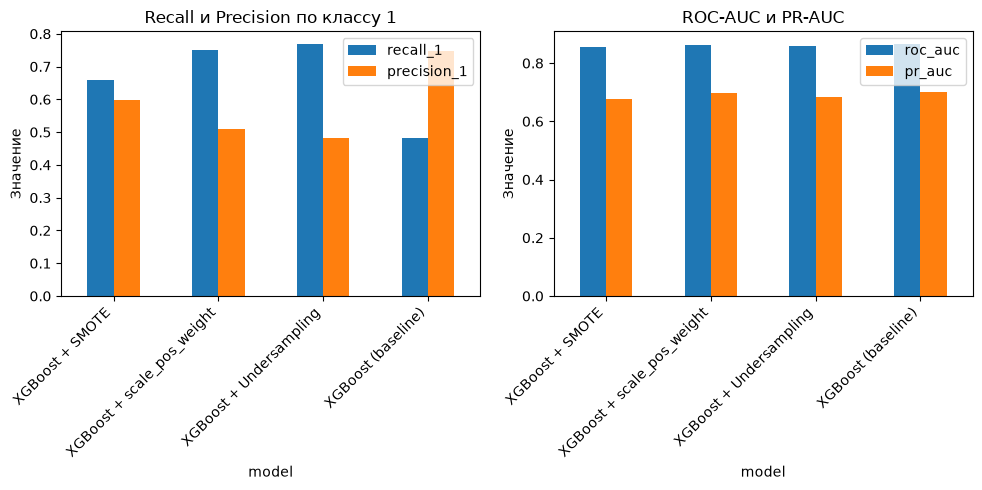

In [274]:
# График сравнения recall и PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df_results.plot(x='model', y=['recall_1', 'precision_1'], kind='bar', ax=axes[0])
axes[0].set_title('Recall и Precision по классу 1')
axes[0].set_ylabel('Значение')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

df_results.plot(x='model', y=['roc_auc', 'pr_auc'], kind='bar', ax=axes[1])
axes[1].set_title('ROC-AUC и PR-AUC')
axes[1].set_ylabel('Значение')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### __Сравнение методов борьбы с дисбалансом__

Мы провели серию экспериментов, тестируя различные подходы к балансировке классов для XGBoost.

#### Анализ ключевых моделей

**1. XGBoost + scale_pos_weight (рекомендуемый вариант)**

- **Recall по классу 1: 0.752** — модель находит 75% уходящих клиентов.
- **Precision: 0.511** — из всех предсказанных ушедших 51% действительно ушли.
- **F1: 0.608** —  баланс между полнотой и точностью.
- **PR‑AUC: 0.698** — второй лучший показатель.
- **Accuracy: 0.803** — немного ниже, чем у baseline, но это ожидаемо при смещении фокуса на миноритарный класс.

**Преимущества:**
- Не требует изменения данных (работает с исходной выборкой).
- Прост в реализации — один параметр `scale_pos_weight`.
- Сохраняет интерпретируемость важности признаков.

**2. XGBoost + SMOTE**

- **Recall: 0.658** — уступает scale_pos_weight и undersampling.
- **Precision: 0.598** — лучший показатель точности среди всех бустингов.
- **F1: 0.627** — самый высокий F1 среди XGBoost-моделей.
- **Accuracy: 0.840** — высокая общая точность.

_С одной стороны точнее предсказывает чем XGBoost + scale_pos_weight, с другой стороны из всего оттока находит меньшее количество клиентов._

**Недостатки:**
- Требует генерации синтетических данных (увеличивает размер выборки на ~60%).
- Может создавать нереалистичные комбинации признаков, что снижает обобщающую способность.
- Меньший recall, чем у scale_pos_weight.

**3. XGBoost + Undersampling**

- **Recall: 0.769** — **самый высокий** среди всех моделей.
- **Precision: 0.483** — самый низкий среди бустингов (много ложных срабатываний).
- **F1: 0.593** — ниже, чем у scale_pos_weight.

**Недостатки:**
- Удаляет 60% данных класса большинства, теряя полезную информацию.
- Может не обобщаться на реальных данных.

---

#### Почему выбираем XGBoost + scale_pos_weight?

1. **Баланс между recall и precision** — модель находит 75% ушедших клиентов с точностью (51%).
2. **Работает с исходными данными** — не требует генерации или удаления наблюдений.
3. **Высокая PR‑AUC (0.698)** — второй лучший показатель, что говорит о хорошем ранжировании вероятностей.
4. **Простота интерпретации** — важность признаков остаётся понятной, так как данные не менялись.
5. **Гибкость** — можно легко менять вес в зависимости от бизнес-приоритетов (например, увеличить `scale_pos_weight` для ещё более высокого recall за счёт точности).

---

## Другие леса

__От дисбаланса классов — к выбору алгоритма.__

Мы убедились, что scale_pos_weight — эффективный и простой способ повысить Recall без изменения данных. Но остаётся открытым вопрос: а что если проблема не только в балансе классов, но и в самом алгоритме? XGBoost — это бустинг, последовательное «усиление» слабых моделей. Альтернативой является случайный лес — ансамбль независимых деревьев, который по-другому обрабатывает шум и взаимодействия признаков. Логично проверить, даст ли смена метода ансамблирования дополнительный прирост качества.

__Random Forest:__ 
Random Forest — это ансамблевый метод, который строит множество деревьев решений на разных подвыборках данных и признаков, а затем усредняет их предсказания. Он хорошо работает с несбалансированными данными, устойчив к шуму и позволяет оценить важность признаков.

#### __Базовая модель:__

In [275]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Параметры Random Forest с учётом дисбаланса
rf_model = RandomForestClassifier(
    n_estimators=200,           # количество деревьев
    max_depth=10,               # максимальная глубина (можно оставить None для полного роста)
    min_samples_split=10,       # минимальное число объектов для разбиения узла
    min_samples_leaf=5,         # минимальное число объектов в листе
    class_weight='balanced',    # автоматическая балансировка классов
    random_state=42,
    n_jobs=-1                   # использовать все ядра
)

# Обучение
rf_model.fit(X_train_tree, y_train)

# Предсказание
y_pred_rf = rf_model.predict(X_test_tree)
y_proba_rf = rf_model.predict_proba(X_test_tree)[:, 1]

# Оценка
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_rf):.3f}")

=== Random Forest ===
Accuracy: 0.809
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1592
           1       0.52      0.74      0.61       407

    accuracy                           0.81      1999
   macro avg       0.72      0.78      0.74      1999
weighted avg       0.84      0.81      0.82      1999

ROC-AUC: 0.858
PR-AUC: 0.675


### __От базовых моделей — к оптимизации.__

Мы получили два базовых результата: XGBoost с scale_pos_weight (Recall = 0.75, Precision = 0.51) и Random Forest с class_weight='balanced' (Recall = 0.74, Precision = 0.52). Оба алгоритма показывают близкие метрики, но с разными профилями: бустинг точнее, лес — полнее. Однако сравнение пока нельзя считать справедливым: гиперпараметры обеих моделей заданы вручную, без систематического поиска.

Дальнейший шаг — __оптимизация гиперпараметров__ для каждой модели. 

Это позволит:

- Убедиться, что каждая модель работает на пределе своих возможностей.
- Сравнить XGBoost и Random Forest в равных условиях.
- Получить финальные модели, пригодные для внедрения.

## Подбор гиперпараметров для XGBoost и Random Forest

__Подход к подбору гиперпараметров__

Для поиска оптимальных гиперпараметров  используем GridSearchCV с трёхкратной стратифицированной кросс-валидацией. GridSearchCV систематически перебирает комбинации параметров и выбрает наилучшие по заданной метрике, избегая переобучения под конкретную валидационную выборку.

In [276]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import make_scorer, recall_score, accuracy_score, classification_report, roc_auc_score, average_precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

#### Выбор метрики оптимизации

Мы протестировали 3 подхода к выбору метрики:

__Recall__

На xgboost показала слишком сильный перекос в сторону Recall (класс 1) на тесте	= 0.92, при этом Precision (класс 1) = 0.33. Даже не смотря на то, что модель правильно находила более 90% оттока, она также совершала ошибки более чем для 60% предсказаний. Поэтому также был выполнен подбор гиперпараметров с метриками сублюдающими баланс между точностью и полнотой.

__PR‑AUC__

(Area Under Precision‑Recall Curve) — оценивает качество ранжирования положительного класса (ушедших клиентов). Эта метрика особенно информативна при сильном дисбалансе классов, так как фокусируется на работе модели с миноритарным классом.

__F1-score__

F1-score — гармоническое среднее между precision и recall для класса «отток». Даёт более сбалансированную оценку при фиксированном пороге классификации (0.5).

В итоге мы остановились на F1-score, так как он обеспечил лучший баланс между полнотой (recall) и точностью (precision) при стандартном пороге, что критически важно для бизнес-задачи удержания клиентов.

In [277]:
# === Препроцессор БЕЗ стандартизации (для деревьев) ===
preprocessor_tree_tree = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
], remainder='passthrough')   # числовые остаются как есть

# Трансформируем данные
X_train_tree = preprocessor_tree_tree.fit_transform(X_train)
X_val_tree = preprocessor_tree_tree.transform(X_val)
X_test_tree = preprocessor_tree_tree.transform(X_test)

# Имена признаков (для интерпретации)
feature_names_tree = preprocessor_tree_tree.get_feature_names_out()

In [278]:
# # ------ Метрика для оптимизации 

# ------- Recall
# scorer = make_scorer(recall_score, pos_label=1)
# -----  PR‑AUC (чем выше, тем лучше)
# scorer = make_scorer(average_precision_score, needs_proba=True) # --needs_proba=True указывает, что метрика требует вероятностей, а не меток классов.
# ------- F1
scorer = make_scorer(f1_score, pos_label=1)

### XGBoost

Для XGBoost мы ограничили диапазон `scale_pos_weight` значениями вокруг отношения классов с помощью `ratio` (соотношение классов).  Это предотвратило чрезмерный перекос в сторону класса меньшинства (как в эксперименте с максимальным весом =10 для меньшнго, где Recall (класс 1) достиг 0.92, а Recall (класс 0) упал до 0.53).

In [279]:
#-----  XGBoost — подбор гиперпараметров (без early_stopping)

# соотношение классов
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Параметры для поиска (без early_stopping и eval_metric)
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [ratio * 0.5, ratio * 0.75, ratio, ratio * 1.25, ratio * 1.5],
    'n_estimators': [100, 150, 200],
}

# Базовый классификатор (без early_stopping)
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    # eval_metric и early_stopping_rounds убраны
)


grid_xgb = GridSearchCV(
    xgb_base,
    xgb_params,
    # ----- метрика оптимизации
    # scoring=f1_scorer,
    scoring=scorer,
# Кросс-валидация (3 фолда для скорости)
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_tree, y_train)

print("Лучшие параметры XGBoost:")
print(grid_xgb.best_params_)
print("Лучший recall (кросс-валидация):", grid_xgb.best_score_)


# Лучшие параметры из GridSearch
best_params = grid_xgb.best_params_.copy()
# Добавляем параметры для ранней остановки
best_params.update({
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10,
    'n_estimators': 200,  # можно оставить запас
})

# Обучаем модель с early stopping на валидации
final_xgb = xgb.XGBClassifier(**best_params, random_state=42, use_label_encoder=False)
final_xgb.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=False
)

# Используем лучшее количество деревьев
print(f"Лучшее число деревьев: {final_xgb.best_iteration}")

# Предсказание на тесте
y_pred = final_xgb.predict(X_test_tree)
y_proba = final_xgb.predict_proba(X_test_tree)[:, 1]

print("\n=== XGBoost tuned (с early stopping) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.3f}")

Fitting 3 folds for each of 1215 candidates, totalling 3645 fits
Лучшие параметры XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1.953355155482815, 'subsample': 0.8}
Лучший recall (кросс-валидация): 0.6279641609114395
Лучшее число деревьев: 197

=== XGBoost tuned (с early stopping) ===
Accuracy: 0.854
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1592
           1       0.66      0.60      0.63       407

    accuracy                           0.85      1999
   macro avg       0.78      0.76      0.77      1999
weighted avg       0.85      0.85      0.85      1999

ROC-AUC: 0.866
PR-AUC: 0.696


### Random Forest

In [280]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)


grid_rf = GridSearchCV(
    rf_base,
    rf_params,
    # ------ оптимизация по метрике
    # scoring=scorer,
    # scoring=f1_scorer,
    scoring=scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_tree, y_train)

print("Лучшие параметры Random Forest:")
print(grid_rf.best_params_)
print(f"Лучший recall (кросс-валидация): {grid_rf.best_score_:.3f}")

# Оценка лучшего Random Forest на тесте
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_tree)
y_proba_rf = best_rf.predict_proba(X_test_tree)[:, 1]

print("\n=== Random Forest tuned ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_rf):.3f}")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Лучшие параметры Random Forest:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Лучший recall (кросс-валидация): 0.611

=== Random Forest tuned ===
Accuracy: 0.831
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1592
           1       0.57      0.66      0.61       407

    accuracy                           0.83      1999
   macro avg       0.74      0.77      0.75      1999
weighted avg       0.84      0.83      0.84      1999

ROC-AUC: 0.859
PR-AUC: 0.672


### Сводная таблица результатов экспериментов

Все результаты были получены повторным запуском кода выше.

|Модель|	Метрика оптимизации|Accuracy|Recall (класс 1)|Precision (класс 1)|F1 (класс 1)|ROC‑AUC|PR‑AUC|
|------|-----------------------|---------|-------------------|----------------------|----------------|----------|----------|
|XGBoost + scale_pos_weight (до подбора)|	–	|0.803	|0.752	|0.511	|0.608	|0.862	|0.698|
|XGBoost (Recall, scale_pos_weight=10)|	Recall	|0.611	|0.920	|0.330	|0.490	|0.864	|0.697|
|XGBoost     (Recall)	|Recall	                |0.741	|__0.840__	|0.430	|0.570	|0.863	|__0.699__|
|XGBoost     (PR‑AUC)	|PR‑AUC	                |0.848	|0.590	|0.640	|0.610	|0.864	|0.696|
|__XGBoost     (F1)__	        |F1	                |__0.854__	|0.600	|__0.660__	|__0.630__	|0.866	|0.696|
|Random Forest (Recall)	|Recall	                |0.798	|0.740	|0.500	|0.600	|0.858	|0.675|
|Random Forest (PR‑AUC)	|PR‑AUC	                |0.796	|0.730	|0.500	|0.590	|0.856	|0.673|
|__Random Forest (F1)__        |F1	                |0.831	|0.660	|0.570	|0.610	|0.859	|0.672|

Для дальнейшего сравнения были выбраны 2 модели: __XGBoost (F1, ограниченные веса)__  и __Random Forest (F1)__

- XGBoost точнее определяет, кто действительно уйдёт (Precision 0.66 против 0.57), но пропускает часть уходящих (Recall 0.60 против 0.66).
- Random Forest находит больше уходящих клиентов (Recall 0.66), но чаще ошибается с ложными срабатываниями.

Для задачи удержания XGBoost даёт лучший баланс — он точнее в предсказаниях и лучше ранжирует клиентов по риску (PR‑AUC).


__Решение:__ оставим обе модели для дальнейшего сравнения. Если после SHAP‑анализа и проверки на бизнес-данных одна из них покажет более стабильные результаты, она станет финальной. Также рассматриваем возможность их объединения через голосование (Voting Classifier) для повышения устойчивости прогнозов.

### __Параметры сравниваемых моделей__

In [281]:
# XGBoost (F1)
best_xgb_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 200,
    'scale_pos_weight': 1.953,  # ≈ ratio * 0.5
    'subsample': 0.8,
    'objective': 'binary:logistic',
    'random_state': 42,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10
}
# Random Forest (F1)

best_rf_params = {
    'class_weight': 'balanced_subsample',
    'max_depth': 10,
    'min_samples_leaf': 2,
    'min_samples_split': 5,
    'n_estimators': 300,
    'random_state': 42
}

### Обучение финальных моделей

In [282]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

In [283]:
# === XGBoost ===
xgb_final = xgb.XGBClassifier(**best_xgb_params)
xgb_final.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=False
)
print(f"XGBoost best_iteration: {xgb_final.best_iteration}")

# === Random Forest ===
rf_final = RandomForestClassifier(**best_rf_params)
rf_final.fit(X_train_tree, y_train)

# === Оценка на тесте ===
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n\t {name} \t")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.3f}")

evaluate_model(xgb_final, X_test_tree, y_test, "XGBoost Final")
evaluate_model(rf_final, X_test_tree, y_test, "Random Forest Final")

XGBoost best_iteration: 191

	 XGBoost Final 	
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1592
           1       0.65      0.60      0.63       407

    accuracy                           0.85      1999
   macro avg       0.78      0.76      0.77      1999
weighted avg       0.85      0.85      0.85      1999

ROC-AUC: 0.866
PR-AUC: 0.697

	 Random Forest Final 	
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1592
           1       0.57      0.66      0.61       407

    accuracy                           0.83      1999
   macro avg       0.74      0.77      0.75      1999
weighted avg       0.84      0.83      0.84      1999

ROC-AUC: 0.859
PR-AUC: 0.672


### __Важность признаков и SHAP__

In [284]:
# import matplotlib.pyplot as plt
# import pandas as pd

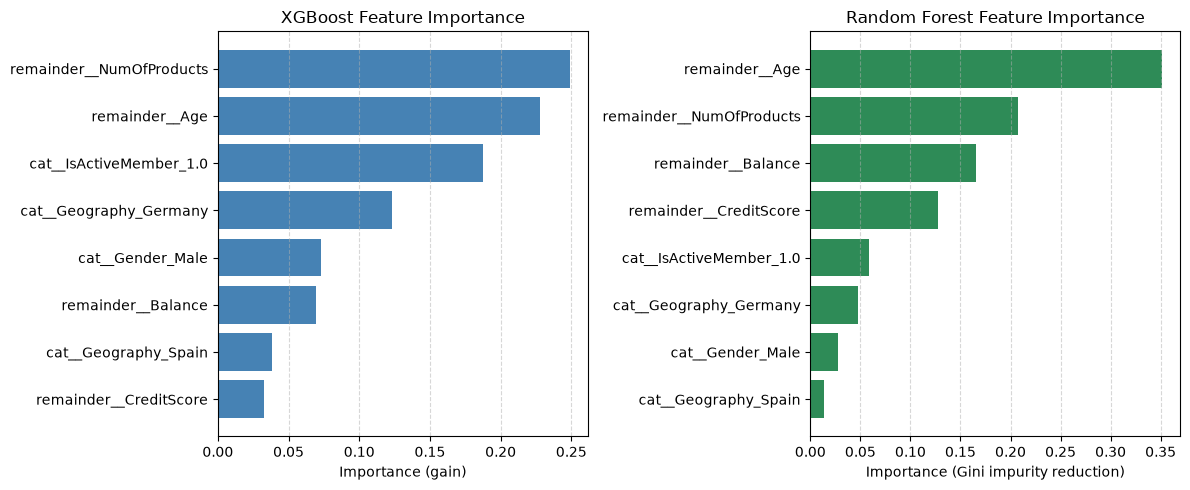

,feature,RF (Gini),XGBoost (gain)
0,remainder__Age,0.352,0.228
1,remainder__NumOfProducts,0.207,0.249
2,remainder__Balance,0.165,0.069
3,remainder__CreditScore,0.128,0.032
4,cat__IsActiveMember_1.0,0.058,0.188
5,cat__Geography_Germany,0.048,0.123
6,cat__Gender_Male,0.028,0.073
7,cat__Geography_Spain,0.014,0.038


In [285]:
# Важность по gain (улучшение качества при разделении)
importance_xgb = pd.DataFrame({
    'feature': feature_names_tree,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

importance_rf = pd.DataFrame({
    'feature': feature_names_tree,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost
axes[0].barh(importance_xgb['feature'], importance_xgb['importance'], color='steelblue')
axes[0].set_xlabel('Importance (gain)')
axes[0].set_title('XGBoost Feature Importance')
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Random Forest
axes[1].barh(importance_rf['feature'], importance_rf['importance'], color='seagreen')
axes[1].set_xlabel('Importance (Gini impurity reduction)')
axes[1].set_title('Random Forest Feature Importance')
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


importance_both=importance_rf.merge(importance_xgb,on='feature')
importance_both=importance_both.rename(columns={'importance_x': 'RF (Gini)', 'importance_y': 'XGBoost (gain)'})
importance_both.round(3)

### Интерпретация важности признаков

Сравнение важности признаков в XGBoost (метрика `gain`) и Random Forest (метрика `Gini`) позволяет оценить, на какие признаки опирается каждая модель и насколько они согласованы.

`gain` и `Gini` — принципиально разные метрики. Их **абсолютные значения несопоставимы** между моделями, поэтому мы сравниваем только **порядок (ранги)** признаков внутри каждой модели.

#### Согласованность моделей

Обе модели сходятся в том, что **`Age` и `NumOfProducts` — ключевые предикторы** оттока (топ-2 в обеих моделях). Это подтверждает результаты EDA и делает вывод устойчивым.

Однако на **третьем месте** модели расходятся:
- **XGBoost:** `IsActiveMember` (3-е место) — активность клиента.
- **Random Forest:** `Balance` (3-е место) — остаток на счёте.

Это отражает разную природу алгоритмов: бустинг последовательно «усиливает» слабые модели и чаще опирается на категориальные признаки с чёткими разбиениями, а случайный лес усредняет независимые деревья и чаще использует числовые признаки с непрерывным разбросом.

#### Ключевые различия в важности

- **Age** - Топ-2 в обеих моделях. RF ставит Age на 1-е место, XGBoost — на 2-е. 
- **NumOfProducts** - Топ-2 в обеих моделях. XGBoost ставит на 1-е место, RF — на 2-е. 
- **IsActiveMember** -XGBoost поднимает активность до топ-3, RF — только на 5-е место. 
- **Geography_Germany**  - XGBoost учитывает страну активнее (4-е vs 6-е место). 
- **Gender_Male**  -  В обеих моделях на периферии, но в XGBoost выше. 
- **Balance**  -  **Самое сильное расхождение.** RF поднимает Balance до топ-3, XGBoost — на 6-е место. 
- **CreditScore** - **Второе по силе расхождение.** RF считает кредитный скор значимым (топ-5), XGBoost — почти игнорирует (последнее место). 
- **Geography_Spain**  -  В обеих моделях на последних местах. 

**Выводы по различиям:**

- **XGBoost** делает ставку на **поведенческие и категориальные признаки**: активность (`IsActiveMember`), страну (`Geography_Germany`), пол (`Gender_Male`). Это признаки с чёткими категориальными различиями, которые бустинг хорошо «разрезает» на каждом шаге.
- **Random Forest** больше опирается на **числовые признаки**: возраст (`Age`), баланс (`Balance`), кредитный скор (`CreditScore`). Это отражает Gini-логику — снижение неопределённости по всей выборке.

### __SHAP__

__SHAP__ (глобальная и локальная интерпретация)

SHAP (SHapley Additive exPlanations) — это метод интерпретации предсказаний моделей, основанный на теории игр. Он показывает, какой вклад каждый признак вносит в предсказание для каждого клиента.

Summary Plot (beeswarm)
Как читать:

- Горизонтальная ось: значение SHAP (вклад признака в предсказание). Положительное значение → признак увеличивает вероятность оттока, отрицательное → снижает.
- Вертикальная ось: признаки, отсортированные по важности (суммарный вклад).
- Цвет: значение признака (красный → высокое, синий → низкое).
- Точки: распределение вклада признака по всем клиентам.

__Замечание__: для __XGBoost__ SHAP-значения выражены в __логарифмических шансах__ (log-odds), а для __Random Forest__ — в __вероятностях__. Поэтому абсолютные величины на осях X у двух графиков разные (от −2 до 4 у XGBoost и от −0.3 до 0.4 у RF). Сравнивать можно __порядок важности__ и __направление влияния__, но не абсолютные значения.

In [286]:
import shap
feature_names_tree = preprocessor_tree_tree.get_feature_names_out()

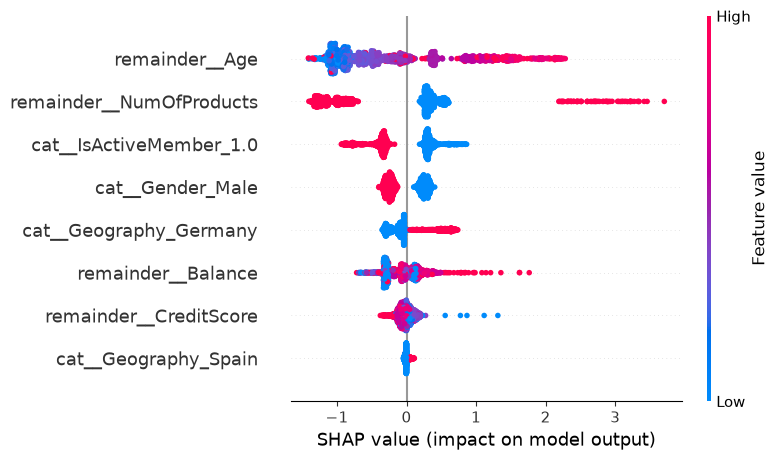

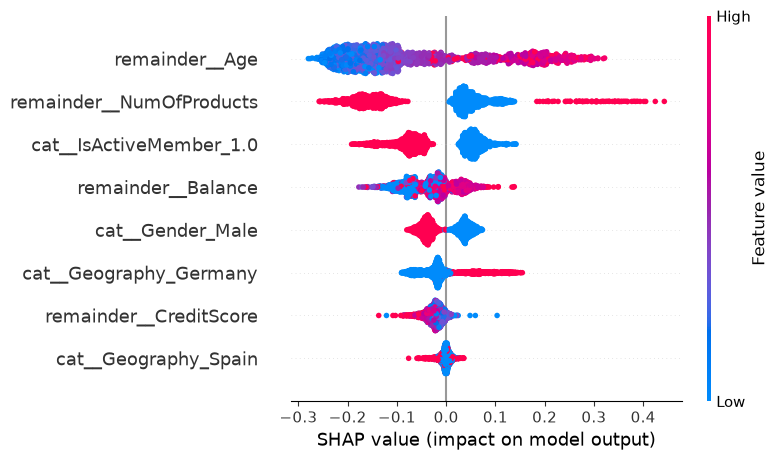

In [287]:


# === XGBoost ===
# Для XGBoost shap_values возвращает двумерный массив (n_samples, n_features) для класса 1
explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values_xgb = explainer_xgb.shap_values(X_test_tree)

# Глобальная важность (XGBoost)
shap.summary_plot(shap_values_xgb, X_test_tree,
                  feature_names=feature_names_tree)

# Локальное объяснение (XGBoost)
shap.force_plot(explainer_xgb.expected_value, shap_values_xgb[0, :],
                X_test_tree[0, :],
                feature_names=feature_names_tree)


# === Random Forest ===
explainer_rf = shap.TreeExplainer(rf_final)
shap_values_rf = explainer_rf.shap_values(X_test_tree)

# В новых версиях shap_values_rf имеет форму (n_samples, n_features, 2)
# Для класса 1 (ушедшие) берём срез [:, :, 1]
shap_values_rf_class1 = shap_values_rf[:, :, 1]

# Глобальная важность (Random Forest)
shap.summary_plot(shap_values_rf_class1, X_test_tree,
                  feature_names=feature_names_tree)

### __Интерпретация__ моделей с помощью SHAP

Мы построили SHAP summary plots для XGBoost и Random Forest, чтобы понять, какие признаки и как влияют на прогноз оттока.

#### Общие закономерности

**`Age` — главный фактор в обеих моделях.**  
Красные точки (высокий возраст) смещены вправо → **с возрастом риск оттока растёт**. Синие (молодые) — влево. Разброс у `Age` — самый широкий среди всех признаков, что подтверждает его ведущую роль.

**`NumOfProducts` — второй по важности.**  
Синие точки (1 продукт) смещены вправо → **один продукт повышает риск**. Красные (2+ продукта) — влево → **больше продуктов снижает риск**.  
Однако в Random Forest заметна вторая красная группа справа — это клиенты с 3+ продуктами, которые тоже уходят чаще. Это согласуется с нашим выводом о «молодых с 3+ продуктами» как о неожиданно проблемной группе.

**`IsActiveMember` — защитный фактор.**  
Синие точки (неактивные, 0) смещены вправо → **неактивность повышает риск**. Красные (активные, 1) — влево → **активность снижает риск**. Это справедливо для обеих моделей.

**`Geography_Germany` — стабильный фактор риска.**  
Красные точки (клиент из Германии) смещены вправо → **немецкие клиенты уходят чаще** во всех моделях.

#### Различия между моделями

| Признак | XGBoost | Random Forest |
|---------|---------|---------------|
| **`Balance`** | Слабый вклад, но красные точки слегка вправо → высокий баланс немного повышает риск | **Более выраженный вклад**: красные точки (высокий баланс) смещены вправо → высокий баланс заметно повышает риск |
| **`CreditScore`** | Практически не влияет — точки сгруппированы у нуля | Слабое влияние, но заметнее, чем в XGBoost |
| **`Gender_Male`** | Красные точки (мужчины) слегка влево → мужчины уходят реже | Аналогично, но вклад слабее |


#### Вывод

- **Возраст** — ключевой фактор. Клиенты 40+ требуют особого внимания.
- **Количество продуктов** — Стимулирование покупки 2-го продукта снижает риск. Но с 3+ продуктами нужно быть осторожнее — там есть проблемная группа.
- **Активность** — Неактивные клиенты уходят в 2 раза чаще.
- **География** — клиенты из Германии в зоне риска.
- **Баланс** — высокий баланс связан с риском, особенно для Random Forest.

---

### Связь важности признаков с ошибками моделей

Различия в важности признаков между XGBoost и Random Forest напрямую отражаются в том, **где именно** модели ошибаются.

#### 1. Germany: XGBoost точнее

Random Forest ошибается в Германии на **5.2 п.п. чаще** (0.269 против 0.217). Это следствие того, что `Geography_Germany` для RF почти не важен (6-е место), а для XGBoost занимает 4-е место.

#### 2. Активные клиенты: XGBoost точнее

Random Forest ошибается на активных клиентах на **3 п.п. чаще** (0.155 против 0.125). Причина: `IsActiveMember` для RF на 5-м месте , а для XGBoost — на 3-м.

#### 3. Калибровка вероятностей

XGBoost лучше калиброван (Brier 0.110 против 0.125), что даёт более точные вероятности и лучшую работу на всех группах клиентов.

#### Вывод

Ошибки моделей **систематичны и объяснимы**: они концентрируются в тех группах, где модель опирается на менее важный для неё признак. XGBoost стабильнее работает на категориальных признаках (страна, активность), Random Forest — на числовых (возраст, баланс, кредитный скор). Это объясняет, почему XGBoost показывает лучшие метрики в целом и особенно на пограничных группах.


=== XGBoost errors by Geography ===
Geography
France     0.125623
Germany    0.216842
Spain      0.120921
dtype: float64
=== XGBoost errors by IsActiveMember ===
IsActiveMember
0.0    0.167683
1.0    0.125123
dtype: float64
=== Random Forest errors by Geography ===
Geography
France     0.145563
Germany    0.269474
Spain      0.122841
dtype: float64
=== Random Forest errors by IsActiveMember ===
IsActiveMember
0.0    0.183943
1.0    0.154680
dtype: float64

---

### __SHAP Interaction Values__

Метод оценивает, насколько совместное влияние двух признаков на предсказание отличается от суммы их индивидуальных вкладов. Функция `shap_interaction_values()` в библиотеке `shap` рассчитывает матрицу взаимодействий для каждого наблюдения. Усредняя эти значения по всей выборке. Это позволяет количественно оценить, какая комбинация (например, Age и NumOfProducts) наиболее важна для модели.

#### Ограничения

- SHAP interaction values показывают **статистические взаимодействия**, а не причинно-следственные связи. Модель может использовать комбинацию, которая не имеет прямого бизнес-смысла.
- Для бинарных признаков значения могут быть завышены из-за резких скачков SHAP-значений.
- Расчёт ресурсоёмкий — использована подвыборка.

In [288]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [289]:
feature_names = preprocessor_tree_tree.get_feature_names_out()
print(f"Размер выборки: {X_test_tree.shape}")

#  Расчёт SHAP interaction values


# Создаём explainer для XGBoost
explainer_xgb = shap.TreeExplainer(xgb_final)

# Расчёт interaction values
# Форма результата: (n_samples, n_features, n_features)
shap_interaction = explainer_xgb.shap_interaction_values(X_test_tree)

print(f"Форма shap_interaction: {shap_interaction.shape}")
print(f"Признаки: {[re.split(r'cat__|remainder__', str)[-1] for str in feature_names]}")

# ---------- Средние абсолютные взаимодействия по парам
# Усредняем по наблюдениям: получаем матрицу (n_features, n_features)
mean_abs_interactions = np.abs(shap_interaction).mean(axis=0)

# Преобразуем в DataFrame
interaction_df = pd.DataFrame(
    mean_abs_interactions,
    index=feature_names,
    columns=feature_names
)
display(interaction_df.round(3))

Размер выборки: (1999, 8)
Форма shap_interaction: (1999, 8, 8)
Признаки: ['Geography_Germany', 'Geography_Spain', 'Gender_Male', 'IsActiveMember_1.0', 'CreditScore', 'Age', 'Balance', 'NumOfProducts']


,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Male,cat__IsActiveMember_1.0,remainder__CreditScore,remainder__Age,remainder__Balance,remainder__NumOfProducts
cat__Geography_Germany,0.288,0.000,0.008,0.009,0.003,0.013,0.107,0.038
cat__Geography_Spain,0.000,0.014,0.004,0.000,0.001,0.012,0.002,0.002
cat__Gender_Male,0.008,0.004,0.237,0.004,0.006,0.018,0.013,0.030
cat__IsActiveMember_1.0,0.009,0.000,0.004,0.392,0.015,0.103,0.005,0.012
remainder__CreditScore,0.003,0.001,0.006,0.015,0.070,0.015,0.010,0.010
remainder__Age,0.013,0.012,0.018,0.103,0.015,0.831,0.017,0.021
remainder__Balance,0.107,0.002,0.013,0.005,0.010,0.017,0.142,0.150
remainder__NumOfProducts,0.038,0.002,0.030,0.012,0.010,0.021,0.150,0.754


		 Топ-10 взаимодействующих пар признаков

,feature_1,feature_2,interaction
27,Balance,NumOfProducts,0.1496
5,Geography_Germany,Balance,0.1072
19,IsActiveMember_1.0,Age,0.1028
6,Geography_Germany,NumOfProducts,0.0379
17,Gender_Male,NumOfProducts,0.0303
26,Age,NumOfProducts,0.0208
15,Gender_Male,Age,0.0181
25,Age,Balance,0.0174
18,IsActiveMember_1.0,CreditScore,0.0155
22,CreditScore,Age,0.0151


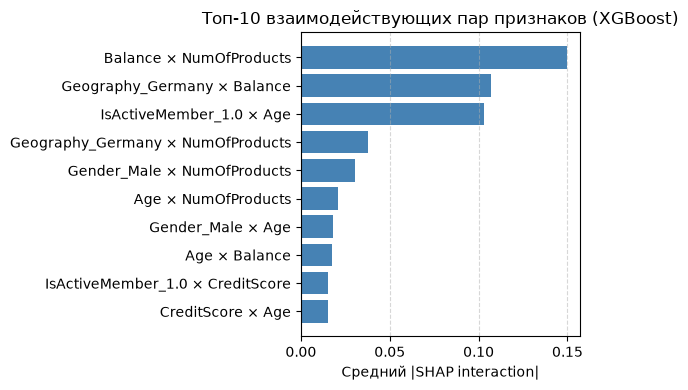

In [290]:
# Берём верхний треугольник без диагонали (матрица симметрична) 
interaction_pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        # print()
        interaction_pairs.append({
            'feature_1': re.split(r'cat__|remainder__', feature_names[i])[-1],
            'feature_2': re.split(r'cat__|remainder__', feature_names[j])[-1],
            'interaction': mean_abs_interactions[i, j]
        })

pairs_df = pd.DataFrame(interaction_pairs).sort_values('interaction', ascending=False)

print("\t\t Топ-10 взаимодействующих пар признаков")
display(pairs_df.head(10).round(4))

# Визуализация топ-10 пар
fig, ax = plt.subplots(figsize=(6, 4))
top_pairs = pairs_df.head(10).iloc[::-1]  # разворачиваем для barh
labels = [f"{row['feature_1']} × {row['feature_2']}" for _, row in top_pairs.iterrows()]
ax.barh(labels, top_pairs['interaction'], color='steelblue')
ax.set_xlabel('Средний |SHAP interaction|')
ax.set_title('Топ-10 взаимодействующих пар признаков (XGBoost)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### SHAP Interaction Values: анализ комбинаций признаков __(для XGBoost)__

После того как мы увидели, **какие признаки** важны (feature importance) и **как их значения влияют** на предсказание (SHAP summary), логично проверить следующий уровень — **какие комбинации признаков использует модель**. __XGBoost__ по своей природе умеет улавливать взаимодействия, и SHAP interaction values позволяют их количественно оценить.

Метод оценивает, насколько **совместное влияние двух признаков** отличается от суммы их индивидуальных вкладов. Мы усреднили абсолютные значения взаимодействий по подвыборке из 3000 наблюдений и выделили самые сильные пары.

#### Взаимодействия __(интерпретация  включает  представление об уровнях признаков и их влиянии на прогноз оттока)__

- **Balance × NumOfProducts** - Главное взаимодействие. Модель различает клиентов с высоким балансом и разным числом продуктов. (Это согласуется с предположением о «накопителях»: высокий баланс в сочетании с 1 продуктом — критический сигнал оттока.)
- **Geography_Germany × Balance** -  Клиенты из Германии с высоким балансом — отдельный сигнал.( Высокий баланс в Германии опаснее, чем в других странах.)
- **IsActiveMember × Age** - Комбинация «неактивный + старший возраст» — усиленный сигнал риска. (Из SHAP summary известно, что неактивность повышает риск, а высокий возраст тоже повышает риск. Наиболее вероятно что это — усиление эффекта возраста для неактивных клиентов.)
- Geography_Germany × NumOfProducts -  Вторичный сигнал: скорее всего это немецкие клиенты с _малым_ числом продуктов.
- Gender_Male × NumOfProducts -  Слабое взаимодействие — пол и число продуктов работают в основном независимо.
- Age × NumOfProducts - ожидалось что эта пару будет в топе, но она на 6-м месте. Модель предпочитает комбинировать `NumOfProducts` с `Balance`, а не с `Age`. 

---

#### Связь взаимодействий с направлениями влияния (из SHAP summary)

Теперь добавим контекст из предыдущего SHAP-анализа — **какие значения признаков участвуют в этих взаимодействиях**:

**Balance × NumOfProducts.**  
Из SHAP summary мы знаем:
- Высокий `Balance` - повышает риск.
- Малый `NumOfProducts` - тоже повышает риск.

Комбинация этих сигналов даёт **синергию**: __клиент с высоким балансом и 1 продуктом__ — это не просто «немного выше риск», а качественно другая группа. По-видимому, это клиенты, которые держат деньги в банке, но не пользуются его продуктами — и уходят в поисках лучших условий.

**Geography_Germany × Balance.**  
- `Geography_Germany = 1` повышает риск оттока.
- Высокий `Balance` - тоже отток.

Модель __«усиливает» риск для немцев с высоким балансом__. Возможно, в Германии другая конкурентная среда или клиенты более требовательны к условиям.

**IsActiveMember × Age.**  
- `IsActiveMember = 0`  - повышение риска.
- Высокий `Age` - повышение риска.

Комбинация __«пожилой + неактивный»__ — это ядро предпологаемой группы «накопителей».

**Почему `Age × NumOfProducts` только на 6-м месте?**  
Из SHAP summary видно, что `NumOfProducts = 1` повышает риск, а `Age` высокий тоже повышает. Но модель комбинирует `NumOfProducts` в первую очередь с **`Balance`**, а не с `Age`. Это означает: **число продуктов работает через баланс**, а не через возраст. То есть «1 продукт + высокий баланс» — более сильный сигнал, чем «1 продукт + пожилой возраст».

---

#### Итог по анализу признаков внутри моделей

Мы прошли три уровня анализа: Feature Importance, SHAP Summary, SHAP Interaction 

**Связь между уровнями:**
- Топ-признаки из importance подтверждаются в SHAP summary (Age, NumOfProducts, IsActiveMember).
-  XGBoost **не ограничивается** отдельными признаками — он использует сложные комбинации, что и объясняет его превосходство над логистической регрессией.

---

#### 4. Взаимодействия в Random Forest

В отличие от бустинга, где деревья строятся последовательно и явно «накладывают» эффекты друг на друга, в случайном лесу деревья **независимы и параллельны**. Это делает интерпретацию взаимодействий принципиально сложнее:

- Каждое дерево в лесу обучается на своей бутстрап-выборке и своём подмножестве признаков.
- Взаимодействия, найденные в одном дереве, могут не воспроизводиться в другом.
- SHAP interaction values для RF дают очень «шумную» картину — значения сильно варьируются между деревьями.

Поэтому для Random Forest мы **не проводим отдельный анализ взаимодействий**. Упрощённое представление о важности признаков (feature importance по Gini) и их направленном влиянии (SHAP summary) уже даёт достаточное понимание модели.

---

#### 5. Ограничения анализа

- **SHAP interaction values показывают статистические взаимодействия**, а не причинно-следственные связи. Модель может использовать комбинацию, которая не имеет прямого бизнес-смысла.
- **Для бинарных признаков** значения могут быть завышены из-за резких скачков SHAP-значений (0 - 1).
- **Расчёт ресурсоёмкий** — для 8000+ наблюдений и 8 признаков используется тестовая подвыборка, что может незначительно сгладить картину.
- **Порядок признаков может меняться** при переобучении на другой подвыборке — это нормальное поведение для SHAP interaction values.


### __Проверка случайности ошибок (аналог остатков для классификации)__
Для классификационных задач нет прямого аналога проверки нормальности остатков, но есть несколько диагностических подходов:

__1. Калибровочный график (Анализ вероятностей vs фактических классов)__

__Что это такое:__
Это график, который показывает, насколько хорошо модель оценивает вероятности. Он строится так:

1. Все предсказанные вероятности разбиваются на бины (например, 10 бинов по 10%).
2. Для каждого бина вычисляется средняя предсказанная вероятность и фактическая доля положительных примеров (ушедших клиентов).
3. Точки наносятся на график (по X — средняя предсказанная вероятность, по Y — фактическая доля).

__Как интерпретировать:__

- __Идеальная калибровка:__ точки лежат на диагональной линии (y = x). Это означает, что если модель предсказывает вероятность 0.7, то в 70% случаев клиент действительно уходит.
- Если точки __выше диагонали__: модель недооценивает риск (предсказывает слишком низкие вероятности). Например, если для бина с предсказанной вероятностью 0.6 фактическая доля составляет 0.75, то модель «стесняется» предсказывать высокие вероятности.
- Если точки __ниже диагонали__: модель переоценивает риск (завышает вероятности).

In [291]:
import numpy as np
from sklearn.calibration import calibration_curve

         Фактическая доля ушедших: [0.031 0.058 0.136 0.209 0.318 0.412 0.474 0.652 0.884 0.907] 
Средняя предсказанная вероятность: [0.053 0.148 0.241 0.347 0.448 0.551 0.654 0.742 0.849 0.945]


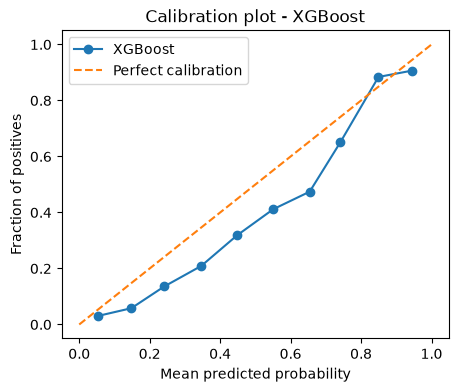

         Фактическая доля ушедших: [0.033 0.028 0.106 0.15  0.251 0.318 0.495 0.615 0.839 0.88 ] 
Средняя предсказанная вероятность: [0.061 0.149 0.247 0.348 0.446 0.545 0.649 0.749 0.848 0.932]


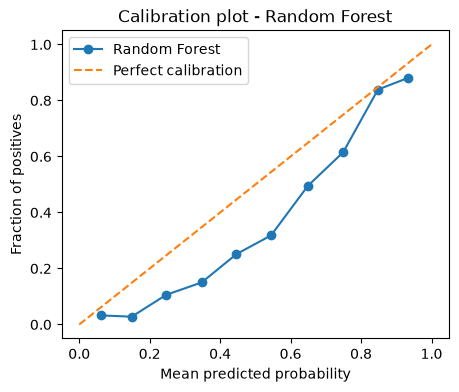

In [292]:
# Для XGBoost
prob_true, prob_pred = calibration_curve(y_test, xgb_final.predict_proba(X_test_tree)[:, 1], n_bins=10)
print('         Фактическая доля ушедших:',prob_true.round(3),'\nСредняя предсказанная вероятность:', prob_pred.round(3))

plt.figure(figsize=(5, 4))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot - XGBoost')
plt.legend()
plt.show()

# Для Random Forest
prob_true, prob_pred = calibration_curve(y_test, rf_final.predict_proba(X_test_tree)[:, 1], n_bins=10)
print('         Фактическая доля ушедших:',prob_true.round(3),'\nСредняя предсказанная вероятность:', prob_pred.round(3))

plt.figure(figsize=(5, 4))
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot - Random Forest')
plt.legend()
plt.show()

__Интерпретация:__

- XGBoost систематически переоценивает вероятность оттока во всех интервалах (предсказанные вероятности выше фактических).
- Random Forest также систематически переоценивает риск, но ещё сильнее, чем XGBoost.

1. Обе модели переоценивают риск. Это означает, что если модель говорит «вероятность оттока 50%», на самом деле клиент уходит примерно в 40% случаев (для XGBoost) или в 25–30% (для Random Forest). Это означает, что при использовании порога 0.5 мы будем классифицировать как «уходящих» многих клиентов, у которых реальный риск ниже. На высоких вероятностях (0.7–0.9) калибровка почти идеальна — этим предсказаниям можно доверять.

2. Для ранжирования переоценка не критична. Если основная задача модели — не точная вероятность, а ранжирование клиентов по риску (например, чтобы выбрать топ-1000 для кампании), то систематическая переоценка не мешает — порядок клиентов сохраняется.

3. Для принятия решений на основе порога (например, «отправить предложение всем клиентам с вероятностью > 0.6») стоит cкорректировать порог вверх (например, использовать 0.65 вместо 0.6), чтобы компенсировать переоценку.

---

## __Ошибки моделей__

__Brier score (аналог MSE для вероятностей)__

Brier score — это среднеквадратичная ошибка вероятностных предсказаний. Формула: (p - y)², где p — предсказанная вероятность, y — фактический класс (0 или 1). Усредняется по всем наблюдениям.

__Диапазон и интерпретация:__

- 0 — идеальная модель (всегда правильно предсказывает с вероятностью 1 или 0).
- 0.5 — модель, предсказывающая случайные вероятности (неприемлемо).
- \>0.5 — хуже, чем случайное угадывание.

In [293]:
from sklearn.metrics import brier_score_loss

brier_xgb = brier_score_loss(y_test, xgb_final.predict_proba(X_test_tree)[:, 1])
brier_rf = brier_score_loss(y_test, rf_final.predict_proba(X_test_tree)[:, 1])
print(f"Brier score XGBoost: {brier_xgb:.4f}")
print(f"Brier score Random Forest: {brier_rf:.4f}")

Brier score XGBoost: 0.1099
Brier score Random Forest: 0.1254


- Brier score XGBoost: 0.1099 — хороший результат, модель даёт точные вероятности.
- Brier score Random Forest: 0.12 — тоже приемлемо, но хуже, чем XGBoost.

XGBoost лучше калиброван, его вероятности ближе к реальным частотам событий. Разница в 0.016 (примерно 15% относительная) заметна, но не критична.

### __Проверка систематичности ошибок моделей__
Так как  сравниваются 2 модели возможны 4 случая классификации: Правильные предсказания обеих моделей, Неправильые предсказания обеих моделей, права только модель бустинга, права только модель случайного леса. 
 Проверим, отличаются ли клиенты из разных групп ошибок по ключевым признакам. Для увеличения размера групп объединили предсказания на тестовой и валидационной выборках.

#### Методы
- **Тест Краскела-Уоллиса** — для сравнения всех 4 групп одновременно.
- **Попарный тест Манна-Уитни** с поправкой Бонферрони — для контроля множественных сравнений.
- **Хи-квадрат** — для категориальных признаков.

In [294]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
from itertools import combinations

In [295]:
# --------------- Собираем предсказания на тесте ---------------
df_test_pred = X_test.copy()
df_test_pred['y_true'] = y_test.values
df_test_pred['xgb_pred'] = xgb_final.predict(X_test_tree)
df_test_pred['rf_pred'] = rf_final.predict(X_test_tree)
df_test_pred['proba_xgb'] = xgb_final.predict_proba(X_test_tree)[:, 1]
df_test_pred['proba_rf'] = rf_final.predict_proba(X_test_tree)[:, 1]

# --------------- Собираем предсказания на валидации ---------------
df_val_pred = X_val.copy()
df_val_pred['y_true'] = y_val.values
df_val_pred['xgb_pred'] = xgb_final.predict(X_val_tree)
df_val_pred['rf_pred'] = rf_final.predict(X_val_tree)
df_val_pred['proba_xgb'] = xgb_final.predict_proba(X_val_tree)[:, 1] 
df_val_pred['proba_rf'] = rf_final.predict_proba(X_val_tree)[:, 1]  

# --------------- Объединяем ---------------
df_all_pred = pd.concat([df_test_pred, df_val_pred], ignore_index=True)

# --------------- Категория сравнения ---------------
def compare(row):
    if row['y_true'] == row['xgb_pred'] == row['rf_pred']:
        return 'Both correct'
    elif row['y_true'] == row['xgb_pred'] and row['y_true'] != row['rf_pred']:
        return 'only RF wrong'
    elif row['y_true'] != row['xgb_pred'] and row['y_true'] == row['rf_pred']:
        return 'only XGB wrong'
    else:
        return 'Both wrong'

df_all_pred['comparison'] = df_all_pred.apply(compare, axis=1)
display(df_all_pred['comparison'].value_counts())

comparison
Both correct      3274
Both wrong         495
only RF wrong      151
only XGB wrong      78
Name: count, dtype: int64

In [296]:
print("NaN в proba_xgb:", df_all_pred['proba_xgb'].isna().sum())
print("NaN в proba_rf:", df_all_pred['proba_rf'].isna().sum())

NaN в proba_xgb: 0
NaN в proba_rf: 0


### Сравнение ошибок XGBoost и Random Forest

Мы объединили предсказания на тестовой и валидационной выборках для увеличения размера групп.

###  Сколько ошибок у каждой модели?

| Категория | Количество | Доля |
|-----------|------------|------|
| **Both correct** (обе правы) | 3274 | 81.9% |
| **Both wrong** (обе ошиблись) | 495 | 12.4% |
| **only RF wrong** (XGB прав) | 151 | 3.8% |
| **only XGB wrong** (RF прав) | 78 | 2.0% |

**Наблюдения:**
- **82% клиентов** обе модели классифицируют одинаково правильно — хорошая согласованность.
- **12.4% — «слепое пятно»:** клиенты, которых обе модели не смогли правильно классифицировать.
- **XGBoost ошибается реже, чем Random Forest**: 151 случай против 78, когда «права» только одна из моделей. Это согласуется с общими метриками: XGBoost точнее.


**Тест Краскела-Уоллиса** — Сравним все 4 группы (`Both correct`, `Both wrong`, `only RF wrong`, `only XGB wrong`) между собой по уровням признаков `CreditScore`, `Age`, `Balance`, `NumOfProducts`

In [297]:
num_features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts']

groups = df_all_pred['comparison'].unique()
results = []

for col in num_features:
    samples = [df_all_pred[df_all_pred['comparison'] == g][col].dropna() for g in groups]
    stat, p = kruskal(*samples)
    results.append({
        'feature': col,
        'kruskal_H': round(stat, 3),
        'p_value': round(p, 4),
        'significant': p < 0.05
    })

results_df = pd.DataFrame(results)
print("\t Kruskal-Wallis test (4 groups) ")
results_df

	 Kruskal-Wallis test (4 groups) 


,feature,kruskal_H,p_value,significant
0,CreditScore,2.924,0.4035,False
1,Age,176.177,0.0000,True
2,Balance,66.082,0.0000,True
3,NumOfProducts,202.482,0.0000,True


__Вывод__: три из четырёх числовых признаков значимо различаются между группами ошибок. Это означает, что ошибки не распределены случайно — они связаны с профилем клиента. 

Проверим между какими конкретно группами есть значимая разница с помощью  __Попарного теста Манна-Уитни__

In [298]:
pairs = list(combinations(groups, 2))
print(pairs)
n_comparisons = len(pairs) * len(num_features)

bonferroni_alpha = 0.05 / n_comparisons

# def cliffs_delta(x, y):
#     """ Cliff's delta — непараметрический размер эффекта."""
#     x, y = np.array(x), np.array(y)
#     n_x, n_y = len(x), len(y)
#     # Считаем, сколько пар (xi, yj) где xi > yj, и сколько где xi < yj
#     gt = sum((xi > y).sum() for xi in x)
#     lt = sum((xi < y).sum() for xi in x)
#     return (gt - lt) / (n_x * n_y)


pairwise_results = []
for col in num_features:
    for g1, g2 in pairs:
        s1 = df_all_pred[df_all_pred['comparison'] == g1][col].dropna()
        s2 = df_all_pred[df_all_pred['comparison'] == g2][col].dropna()
        stat, p = mannwhitneyu(s1, s2, alternative='two-sided')
        pairwise_results.append({
            'feature': col,
            'group1': g1,
            'group2': g2,
            'median_1': round(s1.median(), 2),
            'median_2': round(s2.median(), 2),
            'p_value': round(p, 4),
            # 'delta':cliffs_delta(s1, s2),
            'significant_bonf': p < bonferroni_alpha # альфа уровень значимости сдвинут согласно Поправке Бонферрони
        })

pairwise_df = pd.DataFrame(pairwise_results)
print(f"\nПоправка Бонферрони: alpha = {bonferroni_alpha:.5f}")
display(pairwise_df[pairwise_df['significant_bonf']])


[('Both correct', 'Both wrong'), ('Both correct', 'only RF wrong'), ('Both correct', 'only XGB wrong'), ('Both wrong', 'only RF wrong'), ('Both wrong', 'only XGB wrong'), ('only RF wrong', 'only XGB wrong')]

Поправка Бонферрони: alpha = 0.00208


,feature,group1,group2,median_1,median_2,p_value,significant_bonf
6,Age,Both correct,Both wrong,36.00,42.00,0.0000,True
7,Age,Both correct,only RF wrong,36.00,42.00,0.0000,True
8,Age,Both correct,only XGB wrong,36.00,42.00,0.0000,True
12,Balance,Both correct,Both wrong,91380.76,104016.88,0.0000,True
13,Balance,Both correct,only RF wrong,91380.76,114285.20,0.0000,True
14,Balance,Both correct,only XGB wrong,91380.76,117106.57,0.0000,True
16,Balance,Both wrong,only XGB wrong,104016.88,117106.57,0.0013,True
18,NumOfProducts,Both correct,Both wrong,2.00,1.00,0.0000,True
19,NumOfProducts,Both correct,only RF wrong,2.00,1.00,0.0000,True
20,NumOfProducts,Both correct,only XGB wrong,2.00,1.00,0.0000,True


#### Группа правильно классифиицированных наблюдений значимо отличается от групп ошибок. 

При этом можно зметить что среди групп нет ни одного случая когда была бы значима разница между группами  'only RF wrong', 'only XGB wrong', так же как и между ошибками одной модели и ошибками обеих моделей (Both wrong	) 
**Вывод:** между группами, где ошибается только одна модель (неважно — XGBoost или Random Forest), 
статистически значимых различий по числовым признакам не обнаружено. Это означает что различия в ошибках — это следствие 
разной внутренней логики алгоритмов (какие признаки они используют), а не разных типов клиентов. По сути все найденные ошибки это однородная ошибок.

Также проверим значима ли разница между группами по уровню __категориальных__ признаков с помощью теста __Хи-квадрат__

In [299]:
cat_features = ['Geography', 'Gender', 'IsActiveMember']

for col in cat_features:
    cross = pd.crosstab(df_all_pred['comparison'], df_all_pred[col])
    chi2, p, dof, expected = chi2_contingency(cross)
    print(f"{col}: chi2 = {chi2:.2f}, p = {p:.4f}, {'значимо' if p < 0.05 else 'не значимо'}")

Geography: chi2 = 88.43, p = 0.0000, значимо
Gender: chi2 = 15.77, p = 0.0013, значимо
IsActiveMember: chi2 = 13.57, p = 0.0036, значимо


__Все три категориальных признака значимо различаются между группами ошибок.__

профиль, который модели хуже всего различают:

- Клиенты старше 42 лет.
- С высоким балансом (~100 000+).
- С одним продуктом.
- Часто из Германии, женщины, неактивные.

Такие клиенты представляют собой пограничную группу: по одним признакам они похожи на тех, кто уходит, по другим — на тех, кто остаётся. Отсюда и ошибки обеих моделей.


### __Ошибки моделей и UMAP__

При первом использовании UMAP уже упоминалось для чего к данным применяется стандартизация. Здесь это тоже работает. 

**Эффект стандартизации:**
- На графике проявляется **многомерная структура**: кластеры, разрывы, зоны концентрации.
- Дополнительно отметим, что становятся видны  не только **концентрации клиентов оттока** но и **зоны ошибок моделей** — что критично для интерпретации.

**Важно:** стандартизация применяется **только к визуализациям**, а не к обучению древовидных моделей. Сами модели (XGBoost, Random Forest) обучены на исходных данных, так как деревья решений не чувствительны к масштабу. Мы добавляем стандартизацию локально внутри блока визуализации, чтобы получить корректную проекцию.

In [300]:
import matplotlib.pyplot as plt
import umap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from matplotlib.patches import Patch

Размер данных для UMAP: (3998, 8)
UMAP: (3998, 2)


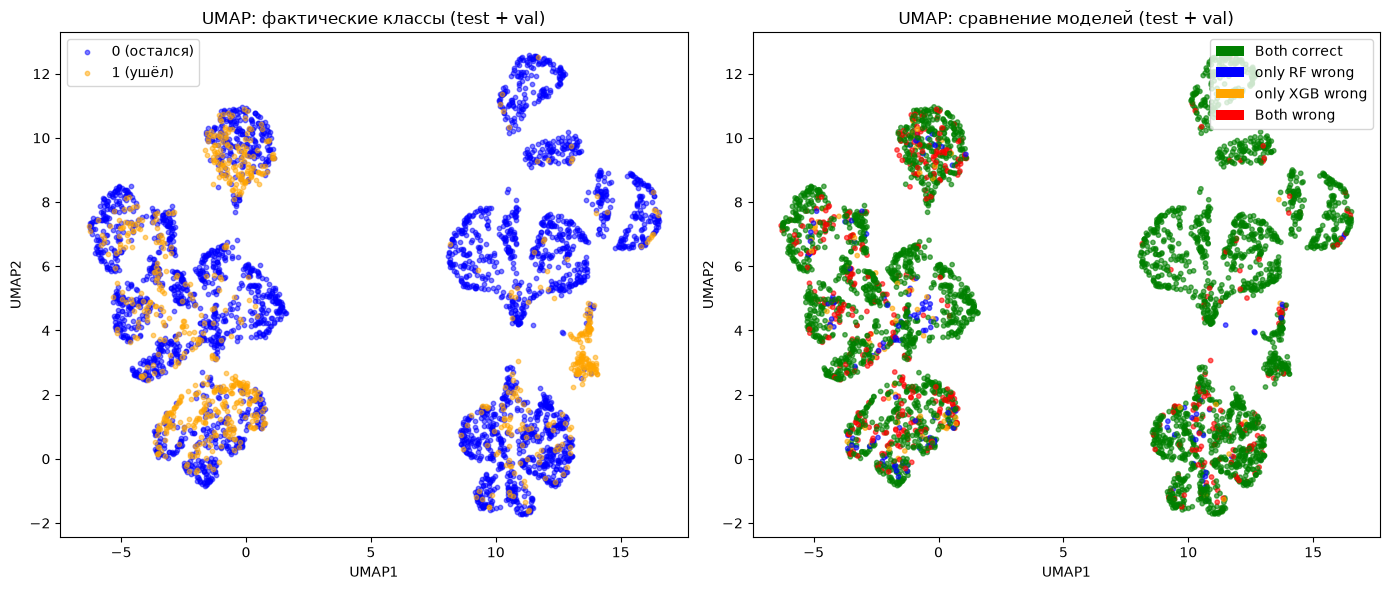

In [301]:
# ----- ----- Препроцессор: One-Hot + StandardScaler

cat_cols_vis = ['Geography', 'Gender', 'IsActiveMember']
num_cols_vis = ['CreditScore', 'Age', 'Balance', 'NumOfProducts']

preprocessor_vis = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_vis),
    ('num', StandardScaler(), num_cols_vis)
])

# fit на train, transform на объединённых test+val
preprocessor_vis.fit(X_train)

# Берём из df_all_pred только исходные признаки (без y_true, xgb_pred, rf_pred, comparison)
feature_cols = cat_cols_vis + num_cols_vis
X_all_vis = df_all_pred[feature_cols]

X_all_vis_scaled = preprocessor_vis.transform(X_all_vis)

print(f"Размер данных для UMAP: {X_all_vis_scaled.shape}")


# ----- ----- UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
X_umap = reducer.fit_transform(X_all_vis_scaled)

print(f"UMAP: {X_umap.shape}")


# ----- ----- Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- График 1: фактические классы ---
y_all = df_all_pred['y_true'].values
mask_0 = y_all == 0
mask_1 = y_all == 1

axes[0].scatter(X_umap[mask_0, 0], X_umap[mask_0, 1],
                c='blue', label='0 (остался)', alpha=0.5, s=10)
axes[0].scatter(X_umap[mask_1, 0], X_umap[mask_1, 1],
                c='orange', label='1 (ушёл)', alpha=0.5, s=10)
axes[0].set_title('UMAP: фактические классы (test + val)')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].legend()

# --- График 2: тип ошибки ---
error_colors = {
    'Both correct': 'green',
    'only RF wrong': 'blue',
    'only XGB wrong': 'orange',
    'Both wrong': 'red'
}

colors = df_all_pred['comparison'].map(error_colors)

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.6, s=10)
axes[1].set_title('UMAP: сравнение моделей (test + val)')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

# Легенда
legend_elements = [Patch(facecolor=v, label=k) for k, v in error_colors.items()]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

### Уверенность моделей: где именно они ошибаются?

Профильная однородность ошибок (нет различий по Age, Balance, NumOfProducts) не означает, что ошибки «одинаковы» по своей природе. 
Проверим **второе измерение** — уверенность моделей, то есть насколько предсказанная вероятность далека от порога 0.5.

In [302]:
df_all_pred.groupby(['comparison','y_true'])[['proba_xgb','proba_rf']].describe().round(3)

proba_xgb                                            \
                          count   mean    std    min    25%    50%    75%   
comparison     y_true                                                       
Both correct   0         2786.0  0.149  0.105  0.008  0.061  0.129  0.214   
               1          488.0  0.799  0.139  0.500  0.678  0.830  0.925   
Both wrong     0          238.0  0.663  0.115  0.503  0.569  0.654  0.719   
               1          257.0  0.252  0.118  0.012  0.162  0.245  0.336   
only RF wrong  0          140.0  0.417  0.058  0.250  0.381  0.433  0.461   
               1           11.0  0.554  0.063  0.501  0.517  0.534  0.548   
only XGB wrong 0           20.0  0.557  0.049  0.502  0.510  0.545  0.610   
               1           58.0  0.436  0.049  0.294  0.415  0.450  0.471   

                             proba_rf                                     \
                         max    count   mean    std    min    25%    50%   
comparison     y_true                                                      
Both correct   0       0.496   2786.0  0.201  0.121  0.015  0.101  0.180   
               1       0.996    488.0  0.787  0.119  0.501  0.686  0.808   
Both wrong     0       0.971    238.0  0.691  0.109  0.502  0.611  0.684   
               1       0.498    257.0  0.309  0.121  0.033  0.220  0.314   
only RF wrong  0       0.500    140.0  0.551  0.037  0.500  0.522  0.546   
               1       0.694     11.0  0.441  0.059  0.316  0.407  0.474   
only XGB wrong 0       0.643     20.0  0.429  0.069  0.288  0.385  0.456   
               1       0.489     58.0  0.563  0.045  0.500  0.530  0.553   

                                     
                         75%    max  
comparison     y_true                
Both correct   0       0.284  0.499  
               1       0.893  0.994  
Both wrong     0       0.768  0.937  
               1       0.408  0.499  
only RF wrong  0       0.572  0.679  
               1       0.484  0.492  
only XGB wrong 0       0.490  0.499  
               1       0.586  0.704

**Boxplot по группам (с разделением по y_true):**

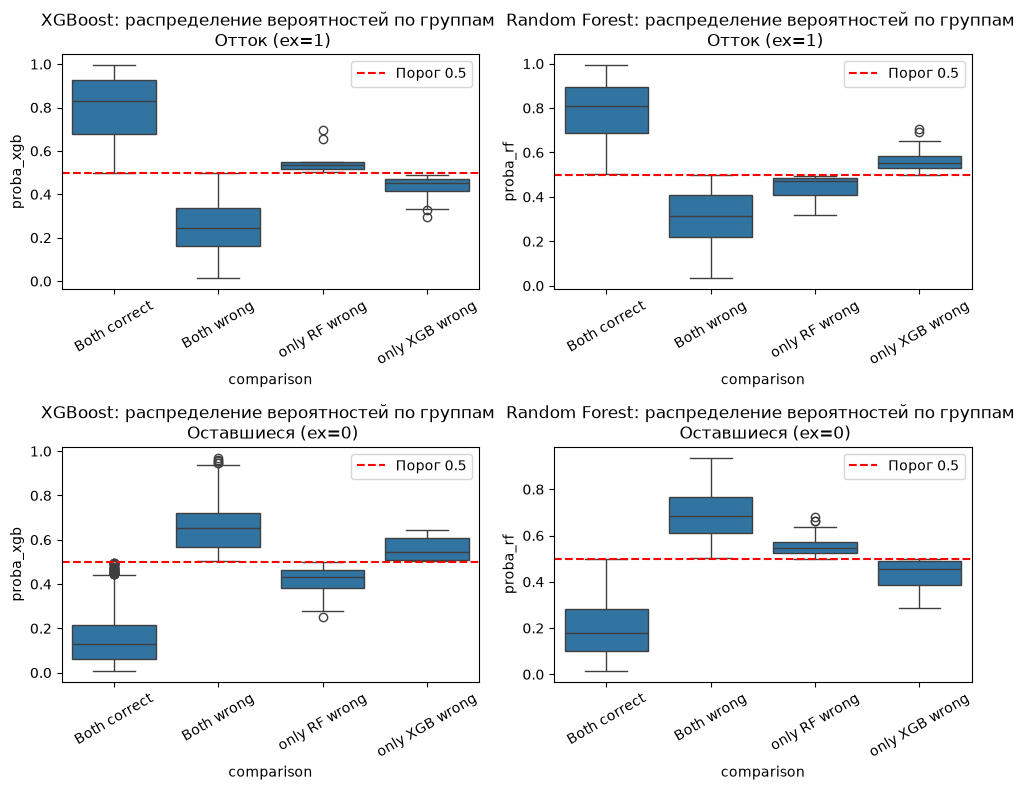

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# XGBoost
sns.boxplot(
    data=df_all_pred[df_all_pred['y_true']==1], x='comparison', y='proba_xgb',
    order=['Both correct', 'Both wrong', 'only RF wrong', 'only XGB wrong'],
    ax=axes[0,0]
)
axes[0,0].axhline(0.5, color='red', linestyle='--', label='Порог 0.5')
axes[0,0].set_title('XGBoost: распределение вероятностей по группам \n Отток (ex=1)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend()

# Random Forest
sns.boxplot(
    data=df_all_pred[df_all_pred['y_true']==1], x='comparison', y='proba_rf',
    order=['Both correct', 'Both wrong', 'only RF wrong', 'only XGB wrong'],
    ax=axes[0,1]
)
axes[0,1].axhline(0.5, color='red', linestyle='--', label='Порог 0.5')
axes[0,1].set_title('Random Forest: распределение вероятностей по группам \n Отток (ex=1)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend()


sns.boxplot(
    data=df_all_pred[df_all_pred['y_true']==0], x='comparison', y='proba_xgb',
    order=['Both correct', 'Both wrong', 'only RF wrong', 'only XGB wrong'],
    ax=axes[1,0]
)
axes[1,0].axhline(0.5, color='red', linestyle='--', label='Порог 0.5')
axes[1,0].set_title('XGBoost: распределение вероятностей по группам \n Оставшиеся (ex=0)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend()

# Random Forest
sns.boxplot(
    data=df_all_pred[df_all_pred['y_true']==0], x='comparison', y='proba_rf',
    order=['Both correct', 'Both wrong', 'only RF wrong', 'only XGB wrong'],
    ax=axes[1,1]
)
axes[1,1].axhline(0.5, color='red', linestyle='--', label='Порог 0.5')
axes[1,1].set_title('Random Forest: распределение вероятностей по группам \n Оставшиеся (ex=0)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend()

plt.tight_layout()
plt.show()

- Верхний ряд (y_true=1, реальные отточники): `Both correct` — уверенно верно (медиана ~0.85); `Both wrong` — уверенно неправильно (медиана ~0.2); `only RF wrong` и `only XGB wrong` — **сгруппированы у порога 0.5** с узким IQR.
- Нижний ряд (y_true=0, реальные оставшиеся): аналогичная картина — `Both correct` далеки от порога, `Both wrong` — уверенно неправильно, single-model ошибки — на грани.

__Margin__ = |proba − 0.5| — _отступ_ от порога, то есть __«насколько модель уверена в своём решении».__

In [304]:
df_all_pred['margin_xgb'] = np.abs(df_all_pred['proba_xgb'] - 0.5)
df_all_pred['margin_rf'] = np.abs(df_all_pred['proba_rf'] - 0.5)

margins = df_all_pred.groupby('comparison')[['margin_xgb', 'margin_rf']].agg(['mean', 'median']).round(3)
display(margins)

margin_xgb        margin_rf       
                     mean median      mean median
comparison                                       
Both correct        0.343  0.367     0.297  0.319
Both wrong          0.207  0.199     0.191  0.186
only RF wrong       0.081  0.062     0.051  0.046
only XGB wrong      0.062  0.049     0.065  0.052

**Метрика margin (|proba − 0.5|):**

- Single-model ошибки — на грани. Медиана отступа 0.05–0.06 — это практически «нулевая» уверенность. Сравните с Both correct (0.32–0.37) и Both wrong (0.19–0.20).

- Разница между XGB и RF в single-model ошибках отсутствует. Margin для only RF wrong (0.05–0.08) и only XGB wrong (0.05–0.07) практически одинаков. То есть обе модели ошибаются на одних и тех же «пограничных» клиентах, причём на одинаково малом отступе.

#### Ключевые выводы

1. **Single-model ошибки — «подбрасывание монетки».** Когда модель выдаёт вероятность 0.48 или 0.52, она находится в зоне, где __сигналы признаков противоречат друг другу и почти уравновешены__. __Разница между «правильным» и «неправильным»__ предсказанием здесь определяется не качеством модели, а скорее случайным смещением весов внутри алгоритма.

2. **XGB и RF одинаково «слепы» в этой зоне.** Margin для `only RF wrong` и `only XGB wrong` практически идентичен — обе модели «видят» этих клиентов с одинаково низкой уверенностью. Разница только в том, в какую сторону они «качнулись».

3. **Три группы ошибок действительно однородны по профилю, но различаются по уверенности:**
   - **Both correct** — высокая уверенность (margin ~0.3).
   - **Both wrong** — средняя уверенность (margin ~0.2).
   - **Single-model errors** — низкая уверенность (margin ~0.06).

#### __Профили групп__

### Слабые места моделей: где и почему они ошибаются

После подтверждения однородности групп ошибок по профилю (нет различий по Age, Balance, NumOfProducts) мы разделили их по **истинному классу** (`y_true`). Это вскрыло разные типы ошибок, каждый из которых — отдельное слабое место моделей.

In [305]:
pd.crosstab(df_all_pred['comparison'], df_all_pred['y_true'], margins=True)

y_true,0,1,All
comparison,,,
Both correct,2786,488,3274
Both wrong,238,257,495
only RF wrong,140,11,151
only XGB wrong,20,58,78
All,3184,814,3998


#### Размеры групп

| Группа | y_true=0 | y_true=1 | Всего |
|--------|----------|----------|-------|
| **Both correct** | 2786 | 488 | 3274 |
| **Both wrong** | 238 | 257 | 495 |
| **single-model** (только одна модель ошиблась) | 160 | 69 | 229 |

Обратите внимание: среди `Both wrong` распределение **сбалансировано** (238 и 257). Среди `single-model` XGB чаще ошибается на классе оттока, а Случайный лес на оставшихся.

In [306]:
# df_all_pred['is_error'] = np.where(df_all_pred['comparison'].isin(['only XGB wrong', 'only RF wrong']), 'Error', 'Correct')


num_features = ['Age', 'Balance', 'NumOfProducts']
cat_features = ['Geography', 'Gender', 'IsActiveMember']

# -------------  Перегруппировка 
# все оставшиеся (Exited=0)
group_kept = df_all_pred[df_all_pred['y_true'] == 0]

# все ушедшие (Exited=1)
group_churned = df_all_pred[df_all_pred['y_true'] == 1]

# правильно классифицированные обеими моделями (Exited=0) (Both correct)
group_correct_0 = df_all_pred[(df_all_pred['comparison'] == 'Both correct')&(df_all_pred['y_true'] == 0)]

# правильно классифицированные обеими моделями (Exited=1) (Both correct)
group_correct_1 = df_all_pred[(df_all_pred['comparison'] == 'Both correct')&(df_all_pred['y_true'] == 1)]

# все ошибки Both wrong (Exited=0)
group_errors_0 = df_all_pred[(df_all_pred['comparison'] == 'Both wrong')&(df_all_pred['y_true'] == 0)]
# все ошибки Both wrong (Exited=1)
group_errors_1 = df_all_pred[(df_all_pred['comparison'] == 'Both wrong')&(df_all_pred['y_true'] == 1)]
#  single-model ошибки (Exited=0)
single_model_0=df_all_pred[((df_all_pred['comparison']=='only XGB wrong')|(df_all_pred['comparison']=='only RF wrong'))&(df_all_pred['y_true'] == 0)]
#  single-model ошибки (Exited=1)
single_model_1=df_all_pred[((df_all_pred['comparison']=='only XGB wrong')|(df_all_pred['comparison']=='only RF wrong'))&(df_all_pred['y_true'] == 1)]


# ----- Числовые профили

def build_profile(df_group, group_name):
    stats = df_group[num_features].describe(percentiles=[0.25, 0.5, 0.75]).T
    stats = stats[[  'min','25%','50%',  '75%', 'max']]
    stats.columns = [  'min','Q1','median',  'Q3', 'max']
    stats['group'] = group_name
    return stats

profiles = pd.concat([
    build_profile(group_kept,    'All kept    (Ex=0)'),
    build_profile(group_churned, 'All churned (Ex=1)'),
    build_profile(group_correct_0, 'Both correct (Ex=0)'),
    build_profile(group_correct_1, 'Both correct (Ex=1)'),
    build_profile(group_errors_0,  'Both wrong (Exited=0)'),
    build_profile(group_errors_1,  'Both wrong (Exited=1)'),
    build_profile(single_model_0,  'single-model (Exited=0)'),
    build_profile(single_model_1,  'single-model (Exited=1)'),
])

display(profiles.sort_index().round(2))

,min,Q1,median,Q3,max,group
Age,18.0,31.00,36.00,41.00,92.00,All kept (Ex=0)
Age,22.0,37.00,42.00,49.25,77.00,single-model (Exited=0)
Age,22.0,35.00,42.00,46.00,61.00,single-model (Exited=1)
Age,18.0,39.00,45.00,51.00,71.00,All churned (Ex=1)
Age,27.0,43.00,46.00,50.00,64.00,Both wrong (Exited=0)
Age,18.0,30.00,35.00,40.00,92.00,Both correct (Ex=0)
Age,18.0,33.00,38.00,42.00,71.00,Both wrong (Exited=1)
Age,24.0,44.00,48.00,53.00,70.00,Both correct (Ex=1)
Balance,0.0,60332.30,104139.46,128457.95,212696.32,Both wrong (Exited=0)
Balance,0.0,80090.93,116520.28,139422.37,206329.65,single-model (Exited=1)



### Профили клиентов по группам

Мы разделили группу «Both correct» на две части — правильно классифицированные оставшиеся (`Ex=0`) и правильно классифицированные ушедшие (`Ex=1`). Это позволяет увидеть, **каких именно клиентов модели «узнают» надёжно**.


| Группа | Age | Balance | NumOfProducts |
|--------|-----|---------|---------------|
| All kept (Ex=0) | 36 | 92 356 | 2 |
| All churned (Ex=1) | 45 | 109 163 | 1 |
| **Both correct (Ex=0)** | **35** | **85 977** | **2** |
| **Both correct (Ex=1)** | **48** | **109 163** | **1** |
| **Both wrong (Ex=0)** | **46** | **104 139** | **1** |
| **Both wrong (Ex=1)** | **38** | **104 017** | **1** |
| **single-model (Ex=0)** | **42** | **115 024** | **1** |
| **single-model (Ex=1)** | **42** | **116 520** | **1** |

**Ключевой вывод:** между «лёгкими» и «сложными» клиентами есть чёткая градация:

1. **Both correct (Ex=0)** — самые «типичные» оставшиеся: моложе (35 лет), ниже баланс (86 000), 2 продукта.
2. **Both wrong** — **промежуточная группа**: 
    - Отток: 38 лет, баланс 104 017, 1 продукт. Профиль ближе к оставшимся, чем к ушедшим.
    - Отавшиеся: 46 лет, баланс 104 139, 1 продукт. 
    - Модели уверенно ошибаются на группе клиентов от 38 до 46 лет, с балансом около 104 000 и одним продуктом. 
3. **single-model** — **самый сложный случай**: и ушедшие клиенты и отавшиеся, примерно в возрасте 42 лет (промеждуток внутри возраста Both wrong),  самый высокий баланс среди групп, и при этом 1 продукт.

**Это означает:** модели **уверенно распознают «крайние» случаи** — очень молодых лояльных и очень «зрелых» уходящих клиентов. А ошибки концентрируются в **«серой зоне»**, где профиль клиента смешанный (особенно промежуточный возраст).

Иными словами, правильно классифицированный отток (Age 48, Германия 46.5%, неактивные 71.7%) — это **более выраженные «ушедшие»**, чем средний ушедший. Модели «узнают» только яркие случаи, а умеренные попадают в ошибки.

### Категориальные показатели: доля внутри группы

In [307]:
def cat_profile(df_group, group_name):
    rows = []
    for col in cat_features:
        vc = df_group[col].value_counts(normalize=True).round(3) * 100
        for cat, share in vc.items():
            rows.append({'group': group_name, 'feature': col, 'category': cat, 'share_%': share})
    return pd.DataFrame(rows)

cat_profiles = pd.concat([
    cat_profile(group_kept,    'All kept    (Ex=0)'),
    cat_profile(group_churned, 'All churned (Ex=1)'),
    cat_profile(group_correct_0, 'Both correct (Ex=0)'),
    cat_profile(group_correct_1, 'Both correct (Ex=1)'),
    cat_profile(group_errors_0,  'Both wrong (Exited=0)'),
    cat_profile(group_errors_1,  'Both wrong (Exited=1)'),
    cat_profile(single_model_0,  'single-model (Exited=0)'),
    cat_profile(single_model_1,  'single-model (Exited=1)'),
])

print("\n доля наблюдений в группе, %")
cat_pivot = cat_profiles.pivot_table(index=['feature', 'category'], columns='group', values='share_%').round(1)
display(cat_pivot)


 доля наблюдений в группе, %


group                    All churned (Ex=1)  All kept    (Ex=0)  \
feature        category                                           
Gender         Female                  56.4                43.5   
               Male                    43.6                56.5   
Geography      France                  40.8                52.6   
               Germany                 38.7                20.4   
               Spain                   20.5                27.0   
IsActiveMember 0.0                     63.9                45.1   
               1.0                     36.1                54.9   

group                    Both correct (Ex=0)  Both correct (Ex=1)  \
feature        category                                             
Gender         Female                   42.0                 60.7   
               Male                     58.0                 39.3   
Geography      France                   54.9                 36.5   
               Germany                  16.9                 46.5   
               Spain                    28.2                 17.0   
IsActiveMember 0.0                      43.8                 71.7   
               1.0                      56.2                 28.3   

group                    Both wrong (Exited=0)  Both wrong (Exited=1)  \
feature        category                                                 
Gender         Female                     58.0                   49.4   
               Male                       42.0                   50.6   
Geography      France                     36.1                   51.0   
               Germany                    47.1                   23.7   
               Spain                      16.8                   25.3   
IsActiveMember 0.0                        61.8                   50.2   
               1.0                        38.2                   49.8   

group                    single-model (Exited=0)  single-model (Exited=1)  
feature        category                                                    
Gender         Female                       48.1                     52.2  
               Male                         51.9                     47.8  
Geography      France                       36.9                     33.3  
               Germany                      41.9                     39.1  
               Spain                        21.2                     27.5  
IsActiveMember 0.0                          43.8                     59.4  
               1.0                          56.2                     40.6

###  Категориальные профили групп

| Признак | Категория | All kept | All churned | Both correct (Ex=0) | Both correct (Ex=1) | **Both wrong (Ex=0)** | **Both wrong (Ex=1)** | **single-model (Ex=0)** | **single-model (Ex=1)** |
|---------|-----------|----------|-------------|---------------------|---------------------|----------------------|----------------------|-------------------------|-------------------------|
| **Gender** | Female | 43.5 | 56.4 | 42.0 | 60.7 | **58.0** | 49.4 | 48.1 | 52.2 |
| **Geography** | Germany | 20.4 | 38.7 | 16.9 | 46.5 | **47.1** | 23.7 | 41.9 | 39.1 |
| | France | 52.6 | 40.8 | 54.9 | 36.5 | 36.1 | 51.0 | 36.9 | 33.3 |
| | Spain | 27.0 | 20.5 | 28.2 | 17.0 | 16.8 | 25.3 | 21.2 | 27.5 |
| **IsActiveMember** | 0 (неактивные) | 45.1 | 63.9 | 43.8 | 71.7 | **61.8** | 43.8 | 50.2 | 59.4 |
| | 1 (активные) | 54.9 | 36.1 | 56.2 | 28.3 | 38.2 | 49.8 | 56.2 | 40.6 |

**Наблюдения:**
- Группа **Both correct (Ex=1)** имеет **самый выраженный «профиль оттока»**: больше всего __женщин (60.7%)__, __немцев (46.5%)__ и __неактивных (71.7%)__. Это и есть __«лёгкие»__ для модели ушедшие.
- Группа **Both wrong осташиеся** по характеристикам больше похожа на __отток__: доля женщин (58%), немцев (47%), неактивных (61%).
- Особенно показателен `IsActiveMember`: среди «лёгких» ушедших 71.7% неактивны, а среди ошибочных — только 43.8%. То есть **модели хуже распознают отток активных клиентов** (противоречие: активность обычно снижает риск, но эти клиенты всё равно ушли).


####  Итоговый вывод

**Ошибки моделей систематичны, а не случайны.** Они концентрируются в «промежуточной» зоне, чей профиль ближе к ушедшим, но **менее выражен**, чем у правильно классифицированного оттока.

**Тип ошибки не связан с профилем клиента.** То, какая именно модель ошибётся (XGBoost или RF), определяется не характеристиками клиента, а внутренней логикой алгоритма. Это подтверждается отсутствием значимых различий между `only RF wrong` и `only XGB wrong`;

**Это фундаментальное свойство данных:** в зоне между классами нет чёткой границы, и любые модели будут ошибаться на «промежуточных» клиентах.

----

### Три слабых места моделей

#### Слабое место 1: «Ложные накопители» (Both wrong, Ex=0)

**Размер:** 238 клиентов.

**Профиль:** Age 46, Balance 104 139, 1 продукт, **Германия 47.1%**, **женщины 58%**, **неактивные 61.8%**.

**Что происходит:** эти клиенты **уверенно предсказаны как отточники** (margin ~0.2), но фактически остались. По всем признакам они **неотличимы от типичного ушедшего** (сравните: All churned — Age 45, Balance 109 163, Germany 38.7%, Female 56.4%, неактивные 63.9%).

**Что это может быть:**
- Клиенты, которые держат крупные сбережения в банке, но не пользуются другими продуктами и **не собираются уходить** — модель ошибочно трактует это как «отток»;
- Клиенты из Германии, но не все «типичные» представители уходят.

**Не так уж и плохо** предсказывает отток для тех, кто по всем признакам похож на отточника, но фактически остаётся. Это клиенты зоны умеренного риска.

---

#### Слабое место 2: «Тихие ушедшие» (Both wrong, Ex=1)

**Размер:** 257 клиентов.

**Профиль:** Age 38, Balance 104 017, 1 продукт, **Германия 23.7%**, женщины 49.4%, неактивные 43.8%.

**Что происходит:** эти клиенты **уверенно предсказаны как лояльные** (margin ~0.2), но фактически **ушли**. По профилю они **не похожи на типичных ушедших** — наоборот, ближе к типичным оставшимся (All kept — Age 36, Germany 20.4%, неактивные 45.1%).

**Что это может быть:**
- Молодые клиенты, которые ушли не из-за неудовлетворенность, а по внешним причинам (переезд, смена работодателя, зарплатный проект в другом банке);
- Клиенты, чей профиль «обманчив» для модели — они выглядят как лояльные, но решение об уходе было принято вне стандартной логики (вне логики имеющихся предикторов).

**Непредсказуемый отток** пропускает реальных отточников, потому что они не вписываются в «типичный» профиль ушедшего.

---

#### Слабое место 3: «Пограничные клиенты» (single-model ошибки)

**Размер:** 229 клиентов (160 Ex=0 + 69 Ex=1).

**Профиль:** Age 42, Balance ~116 000, 1 продукт, Германия ~40%, женщины ~50%, неактивные ~55%.

**Что происходит:** **обе модели «на грани»** (margin ~0.06). Тип ошибки (какая именно модель ошиблась) определяется не профилем клиента, а случайными различиями в весах алгоритмов. Профили для Ex=0 и Ex=1 **почти идентичны** — модель не может отличить «пограничного отточника» от «пограничного лояльного».

**Что это может быть:**
- Клиенты, чьи сигналы признаков **противоречат друг другу** — например, «молодой (момложе типичного оттока) + 1 продукт + высокий баланс» или «женщина + Германия + активная»;
- Клиенты в **зоне размытой границы** — здесь нет чёткого сигнала только в одну сторону.

**Модель не ошибается систематически** — она просто не видит сигнала. Это фундаментальное свойство данных: в зоне между классами любая модель будет «подбрасывать монетку».

---

### Резюме

Разделение ошибок по истинному классу показало **три принципиально разных слабых места моделей**:

| Слабое место | Размер | Тип ошибки | Причина |
|--------------|--------|------------|---------|
| **«Ложные накопители»** | 238 | Систематическая (I рода) | Клиенты похожи на уходящих, но остались |
| **«Тихие ушедшие»** | 257 | Систематическая (II рода) | Клиенты похожи на лояльных, но ушли |
| **«Пограничные»** | 229 | Фундаментальная | Сигналы противоречат, модель не видит |

## __LIME__ (локальные объяснения)

In [308]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

### __Выбор «типичного» клиента: метод k-medoids__

Чтобы построить LIME-объяснения на **репрезентативном** клиенте из каждой группы, нам нужно найти наблюдение, которое наилучшим образом отражает «средний» профиль группы. Простой подход — взять клиента, ближайшего к вектору медиан по каждому признаку — имеет слабое место: точка `(median_Age, median_Balance, median_NumOfProducts)` может **не существовать в данных**, и ближайшее к ней наблюдение окажется не самым представительным.

Более надёжный метод — **k-medoids** (или PAM, Partitioning Around Medoids). Это аналог K-Means, но в качестве центров кластеров используются **реальные наблюдения** из данных, а не виртуальные средние.

#### Как работает медоид

1. Для каждого наблюдения в группе вычисляется **сумма расстояний** до всех остальных наблюдений (по стандартизованным признакам, чтобы масштаб не влиял).
2. **Медоид** — это наблюдение с **минимальной суммой расстояний**. Оно наиболее «центрально» расположено относительно всей группы.
3. В отличие от среднего, медоид **всегда существует в данных** и **устойчив к выбросам**: единичные аномальные клиенты не «сдвигают» его, как это происходит с центроидом.


__Преимущество для LIME-анализа__ - **Реальный клиент.** LIME строит локальное объяснение вокруг конкретного наблюдения. Медоид — это реальный клиент с реальным профилем, а не «усреднённый портрет».

In [309]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import lime
import lime.lime_tabular

In [310]:
def find_medoid(df_group, features):
    """
    Находит клиента, минимизирующего сумму расстояний
    до всех остальных клиентов группы.
    """
    # Стандартизация, чтобы масштаб признаков не влиял
    scaler = StandardScaler()
    X = scaler.fit_transform(df_group[features])
    # Попарные евклидовы расстояния
    # Для n < 500 это мгновенно; для больших групп можно использовать sklearn.metrics.pairwise_distances
    D = pairwise_distances(X)
    # Сумма расстояний от каждой точки до всех остальных
    sum_distances = D.sum(axis=1)
    # Медоид — точка с минимальной суммой
    medoid_local_idx = np.argmin(sum_distances)
    # Возвращаем глобальный индекс (в df_all_pred)
    return df_group.index[medoid_local_idx]


features_for_median = ['Age', 'Balance', 'NumOfProducts']

# --- Подгруппы среди которых ищем медоиды (переменные определены в блоке выше) 
subgroups = {
    'Both correct (Ex=0)':     group_correct_0,
    'Both correct (Ex=1)':     group_correct_1,
    'Both wrong (Ex=0)':       group_errors_0,
    'Both wrong (Ex=1)':       group_errors_1,
    'single-model (Ex=0)':     single_model_0,
    'single-model (Ex=1)':     single_model_1,
}

typical_indices = {}
for name, df_group in subgroups.items():
    idx = find_medoid(df_group, features_for_median)
    typical_indices[name] = idx
    print(f"\n{name}: index = {idx}, размер группы = {len(df_group)}")

    print(f"  Age={df_all_pred.loc[idx, 'Age']}, "
          f"Balance={df_all_pred.loc[idx, 'Balance']:.0f}, "
          f"NumOfProducts={df_all_pred.loc[idx, 'NumOfProducts']}, "
          f"Geography={df_all_pred.loc[idx, 'Geography']}, "
          f"IsActive={df_all_pred.loc[idx, 'IsActiveMember']}")
    print(f"  y_true={df_all_pred.loc[idx, 'y_true']}, "
          f"XGB_pred={df_all_pred.loc[idx, 'xgb_pred']} ({df_all_pred.loc[idx, 'proba_xgb']:.3f}), "
          f"RF_pred={df_all_pred.loc[idx, 'rf_pred']} ({df_all_pred.loc[idx, 'proba_rf']:.3f})")


Both correct (Ex=0): index = 428, размер группы = 2786
  Age=36.0, Balance=58571, NumOfProducts=2, Geography=Germany, IsActive=0.0
  y_true=0, XGB_pred=0 (0.055), RF_pred=0 (0.080)

Both correct (Ex=1): index = 2077, размер группы = 488
  Age=48.0, Balance=100900, NumOfProducts=1, Geography=Germany, IsActive=0.0
  y_true=1, XGB_pred=1 (0.846), RF_pred=1 (0.911)

Both wrong (Ex=0): index = 3783, размер группы = 238
  Age=46.0, Balance=102785, NumOfProducts=1, Geography=Germany, IsActive=1.0
  y_true=0, XGB_pred=1 (0.753), RF_pred=1 (0.832)

Both wrong (Ex=1): index = 2380, размер группы = 257
  Age=37.0, Balance=90433, NumOfProducts=1, Geography=Germany, IsActive=1.0
  y_true=1, XGB_pred=0 (0.258), RF_pred=0 (0.266)

single-model (Ex=0): index = 2307, размер группы = 160
  Age=43.0, Balance=113568, NumOfProducts=1, Geography=Spain, IsActive=0.0
  y_true=0, XGB_pred=0 (0.459), RF_pred=1 (0.536)

single-model (Ex=1): index = 882, размер группы = 69
  Age=41.0, Balance=112610, NumOfProduc

In [311]:
#  lime использует функции предсказаний моделей и данные, в том виде в котором их принимает функция предсказания
#  в нашем случае с закодированными ктегориальными признаками
# поэтому  Извлекаем признаки из df_all_pred и трансформируем
# ============================================================

# Исходные признаки (в порядке препроцессора)
feature_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'Geography', 'Gender', 'IsActiveMember']

# Берём из df_all_pred только исходные признаки и толко отобранные МЕДОИДЫ
X_all_tree = df_all_pred.loc[typical_indices.values(),feature_cols]
X_all_tree_transformed = preprocessor_tree_tree.transform(X_all_tree)

# Прогнозы обеих моделей на трансформированных данных
# proba_xgb_all = xgb_final.predict_proba(X_all_tree_transformed)[:, 1]
# proba_rf_all = rf_final.predict_proba(X_all_tree_transformed)[:, 1]

print(f"Размер трансформированных данных: {X_all_tree_transformed.shape}")

Размер трансформированных данных: (6, 8)


In [312]:
# --------- Инициализация LIME
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_tree, # Обучающие данные (NumPy array или DataFrame) 
    feature_names=preprocessor_tree_tree.get_feature_names_out(), # Список имён признаков
    class_names=['Остался', 'Ушёл'], # Список имён классов 
    mode='classification', # Режим: 'classification' или 'regression'
    random_state=42
)
# --------- plots
def plot_lime_bars(exp, ax, title, num_top=8):
    """Строит горизонтальный bar chart LIME-объяснения на заданной оси."""
    # Берём топ-N признаков
    features_weights = exp.as_list()[:num_top]
    features = [f[0] for f in features_weights][::-1]  # разворачиваем для barh
    weights = [f[1] for f in features_weights][::-1]

    colors = ['green' if w < 0 else 'red' for w in weights]

    ax.barh(features, weights, color=colors)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('LIME weight')
    ax.set_title(title)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# ---------- LIME 
def show_lime_pair(idx, group_name):
    """Показывает LIME-объяснения XGBoost и RF для одного клиента."""
    print("\t\t Группа: ",group_name)

    client_idx=typical_indices[group_name]
    print('client_idx=', client_idx)

    print(f"Клиент #{client_idx}: "
          f"Age={df_all_pred.loc[client_idx, 'Age']}, "
          f"Balance={df_all_pred.loc[client_idx, 'Balance']:.0f}, "
          f"NumOfProducts={df_all_pred.loc[client_idx, 'NumOfProducts']}, "
          f"Geography={df_all_pred.loc[client_idx, 'Geography']}, "
          f"IsActive={df_all_pred.loc[client_idx, 'IsActiveMember']}")
    print(f"y_true={df_all_pred.loc[client_idx, 'y_true']}, "
        f"XGB_proba={df_all_pred.loc[client_idx,'proba_xgb']:.3f}, "
        f"RF_proba={df_all_pred.loc[client_idx,'proba_rf']:.3f}")

    x_client = X_all_tree_transformed[idx]
    # LIME-объяснения
    exp_xgb = explainer_lime.explain_instance(
        x_client, # Одномерный массив (NumPy) или Series
        xgb_final.predict_proba, # функция прогнозирования.
        num_features=len(preprocessor_tree_tree.get_feature_names_out()) # Максимальное число признаков в объяснении
    )
    exp_rf = explainer_lime.explain_instance(
        x_client, rf_final.predict_proba,
        num_features=len(preprocessor_tree_tree.get_feature_names_out())
    )

    # Два графика в одну строку
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_lime_bars(exp_xgb, axes[0], f'LIME: XGBoost\n({group_name})')
    plot_lime_bars(exp_rf, axes[1], f'LIME: Random Forest\n({group_name})')
    plt.tight_layout()
    plt.show()

    # Топ-5 признаков
    # print("\nXGBoost — топ-5 признаков:")
    # for feat, weight in exp_xgb.as_list()[:5]:
    #     print(f"  {feat}: {weight:+.4f}")

    # print("\nRandom Forest — топ-5 признаков:")
    # for feat, weight in exp_rf.as_list()[:5]:
    #     print(f"  {feat}: {weight:+.4f}")

# ----------------------------------------------------------
# прогон по всем группам
# groups=['Both correct (Ex=0)', 'Both correct (Ex=1)', 'Both wrong (Ex=0)', 'Both wrong (Ex=1)', 'single-model (Ex=0)', 'single-model (Ex=1)']
# for i in range(len(groups)):
#     show_lime_pair(i, groups[i])

#### LIME-анализ: локальные объяснения слабых мест моделей
Мы выбрали по одному «типичному» (медоиду) клиенту из каждой подгруппы — с разделением по истинному классу и типу ошибки. Это позволило связать глобальные выводы (три слабых места моделей) с локальными объяснениями LIME для конкретных клиентов.

__Обозначения__: зелёные столбцы — признак снижает вероятность оттока, красные — повышает.

		 Группа:  Both correct (Ex=0)
client_idx= 428
Клиент #428: Age=36.0, Balance=58571, NumOfProducts=2, Geography=Germany, IsActive=0.0
y_true=0, XGB_proba=0.055, RF_proba=0.080


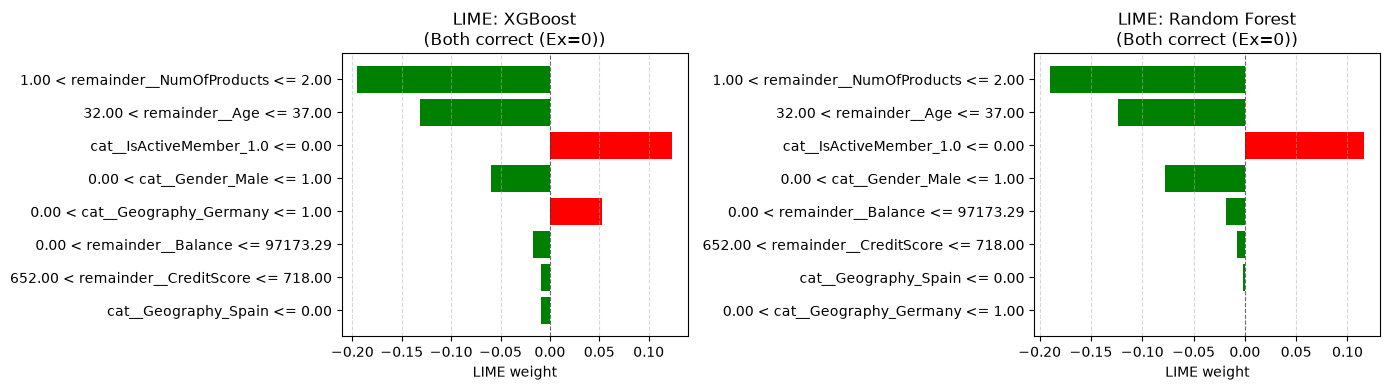

In [313]:
show_lime_pair(0,'Both correct (Ex=0)')

__Both correct (Ex=0)__ — клиент 428

__Профиль__: 36 лет, 2 продукта, Германия, неактивный, баланс 58 571.

__Факт__: остался. Обе модели верно предсказали (XGB = 0.055, RF = 0.080).

__Вывод__: молодой возраст и 2 продукта перевешивают риски (неактивность, Германия). Обе модели согласованы, вероятности уверенно ниже порога.

		 Группа:  Both correct (Ex=1)
client_idx= 2077
Клиент #2077: Age=48.0, Balance=100900, NumOfProducts=1, Geography=Germany, IsActive=0.0
y_true=1, XGB_proba=0.846, RF_proba=0.911


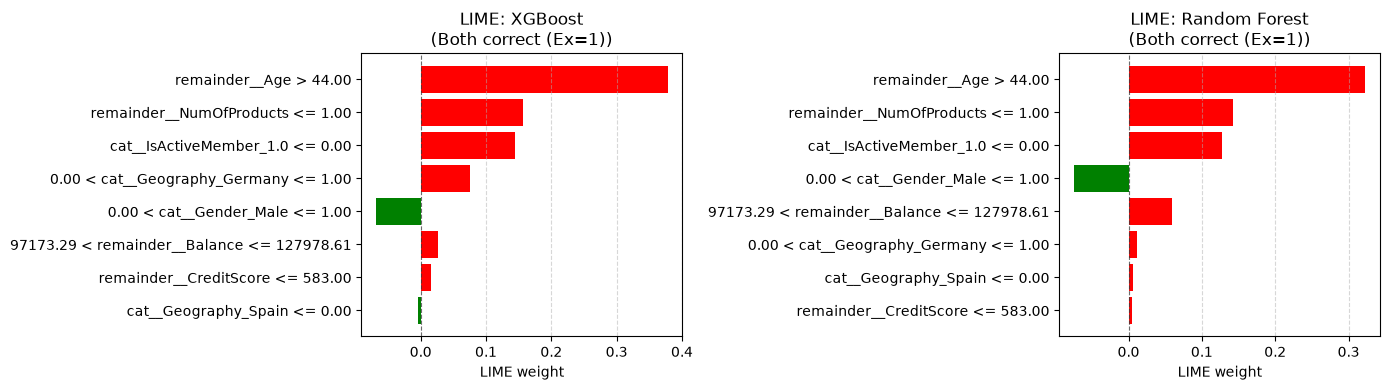

In [314]:
show_lime_pair(1,'Both correct (Ex=1)')

__Both correct (Ex=1)__ — клиент 2077
__Профиль__: 48 лет, 1 продукт, Германия, неактивный, баланс 100 900.

__Факт__: ушёл. Обе модели верно предсказали (XGB = 0.846, RF = 0.911).

__Вывод__: «пожилой + 1 продукт + неактивный + Германия» — классический профиль «накопителя». Обе модели уверены, объяснения согласованы. Контраст с 1.1 показывает, как выглядит «уверенный отток».

__Общий вывод по правильным классификациям:__ в «лёгких» случаях модели согласованы и уверены — LIME-объяснения совпадают по составу и знаку.  Особенно сильно риск оттока повышает/понижает возраст.

		 Группа:  Both wrong (Ex=0)
client_idx= 3783
Клиент #3783: Age=46.0, Balance=102785, NumOfProducts=1, Geography=Germany, IsActive=1.0
y_true=0, XGB_proba=0.753, RF_proba=0.832


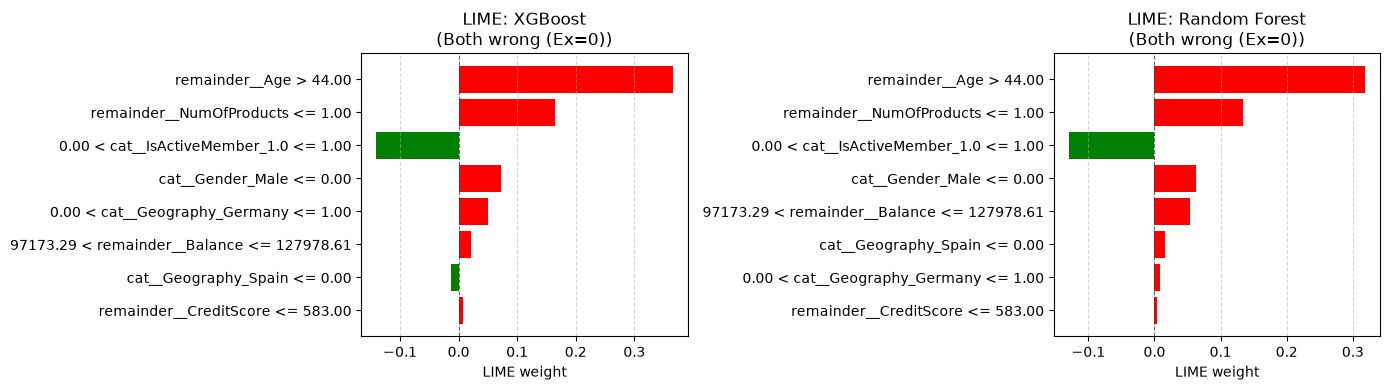

In [315]:
show_lime_pair(2,'Both wrong (Ex=0)')

__Both wrong (Ex=0)__ — «Ложные накопители» — клиент 3783

__Профиль:__ 46 лет, 1 продукт, Германия, активный, баланс 102 785.

__Факт__: остался, но обе модели уверенно предсказали отток (XGB = 0.753, RF = 0.832).

__Что происходит:__ профиль почти идентичен клиенту 2077 из блока 1.2 (который действительно ушёл). Разница: 3783 — женщина и активная. Но активности недостаточно, чтобы перевесить «возраст > 44 + 1 продукт + Германия». Модели «перевешивают» в сторону оттока, но клиент остался.

__Это систематическая ошибка I рода:__ модель видит «типичного накопителя», но конкретный клиент остался. Причина — вероятно, внешние факторы, не отражённые в данных (например, удовлетворённость обслуживанием, отсутствие подходящей альтернативы).

		 Группа:  Both wrong (Ex=1)
client_idx= 2380
Клиент #2380: Age=37.0, Balance=90433, NumOfProducts=1, Geography=Germany, IsActive=1.0
y_true=1, XGB_proba=0.258, RF_proba=0.266


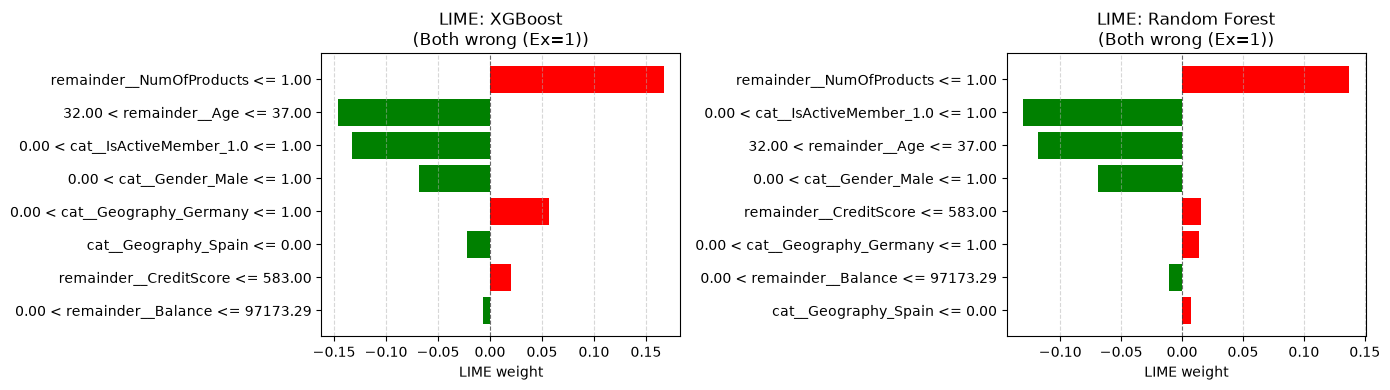

In [316]:
show_lime_pair(3,'Both wrong (Ex=1)')

__Both wrong (Ex=1)__ — «Тихие ушедшие» — клиент 2380

__Профиль__: 37 лет, 1 продукт, Германия, активный, баланс 90 433.

__Факт__: ушёл, но обе модели уверенно предсказали лояльность (XGB = 0.258, RF = 0.266).

__Что происходит:__ профиль __не похож__ на «типичного ушедшего». Молодой возраст, активность и мужской пол — все сигналы стабильности. Только «1 продукт» и «Германия» дают риск, но их недостаточно. Модели уверенно предсказывают «остался», а клиент уходит.

__Это систематическая ошибка II рода:__ модель не видит реальных причин ухода.

__Сравнение с «правильными» ушедшими__
Клиент #2380 (тихий ушедший) контрастирует с клиентом #2077 (правильно классифицированный ушедший). Именно активность и молодой возраст «обманывают» модель — они «тянут» предсказание в сторону лояльности, и модель не видит, что клиент ушёл.

		 Группа:  single-model (Ex=0)
client_idx= 2307
Клиент #2307: Age=43.0, Balance=113568, NumOfProducts=1, Geography=Spain, IsActive=0.0
y_true=0, XGB_proba=0.459, RF_proba=0.536


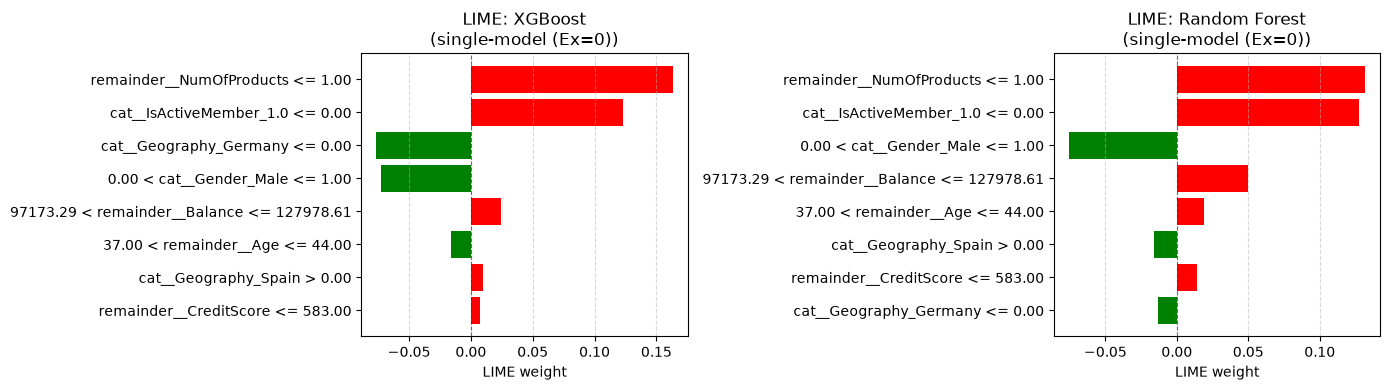

		 Группа:  single-model (Ex=1)
client_idx= 882
Клиент #882: Age=41.0, Balance=112610, NumOfProducts=1, Geography=France, IsActive=0.0
y_true=1, XGB_proba=0.433, RF_proba=0.538


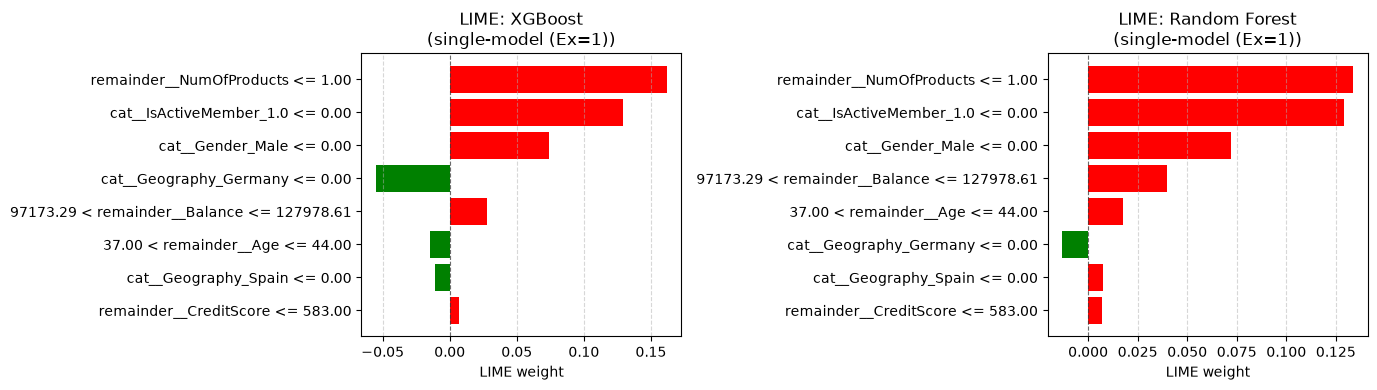

In [317]:
show_lime_pair(4,'single-model (Ex=0)')
show_lime_pair(5,'single-model (Ex=1)')

__single-model (Ex=0)__ — клиент 2307

__Профиль__: 43 года, 1 продукт, Испания, неактивный, баланс 113 568.

__Факт__: остался. XGB верно предсказал (0.459), RF ошибся (0.536).

__single-model (Ex=1)__— клиент 882

__Профиль__: 41 год, 1 продукт, Франция, неактивный, баланс 112 610.

__Факт__: ушёл. XGB ошибся (0.433), RF верно предсказал (0.538).

__Ключевое наблюдение:__ профили #2307 и #882 почти идентичны — 43 и 41 год, баланс 113k и 112k, 1 продукт, неактивный, Испания vs Франция. Исходы разные: #2307 остался, #882 ушёл.

__LIME-объяснения тоже почти идентичны__— одинаковый состав и знак признаков. Отличие: XGB даёт #2307 «−0.077» за «НЕ Германия», а #882 «−0.055». Это _на границе значимости_ — минимальное различие в весах смещает предсказание XGB в разные стороны.

__Что это означает:__ в пограничной зоне сигналы признаков почти уравновешены. Тип ошибки (какая модель ошиблась) определяется случайными различиями в весах алгоритмов, а не профилем клиента. Это подтверждает вывод о фундаментальной неопределённости в зоне размытой границы между классами.

---

### __Объединение XGBoost и Random Forest__

Полученный вывод подводит к голосованию (Voting Classifier): поскольку модели ошибаются на одних и тех же клиентах, но по разным причинам, объединение их предсказаний может дать более устойчивый результат. Даже если прирост F1 будет небольшим, голосование снизит дисперсию предсказаний и сделает модель менее чувствительной к слабостям отдельного алгоритма.

In [318]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, classification_report
)

## Объединение моделей: голосование и блендинг

У нас есть две финальные модели с близкими метриками, но разной логикой:
- **XGBoost (F1)** — точнее (Precision = 0.654), лучше ранжирует (PR‑AUC = 0.697).
- **Random Forest (F1)** — полнее (Recall = 0.658), но менее точен.

Проверим, даст ли объединение моделей прирост качества. Рассмотрели четыре подхода: **Soft Voting**, **Hard Voting (И, ИЛИ)** и **взвешенное голосование** с разными весами.

---

### 1. Soft Voting (усреднение вероятностей)

**Идея:** усредняем вероятности обеих моделей и классифицируем по порогу 0.5. Это снижает дисперсию предсказаний и часто улучшает ранжирование.

In [319]:
# --------- Soft Voting (усреднение вероятностей)

# Вероятности от каждой модели
p_xgb = xgb_final.predict_proba(X_test_tree)[:, 1]
p_rf = rf_final.predict_proba(X_test_tree)[:, 1]

# Soft Voting = среднее арифметическое
p_soft = (p_xgb + p_rf) / 2
y_pred_soft = (p_soft >= 0.5).astype(int)

print("\tSoft Voting (50/50) ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_soft):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_soft, pos_label=1):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_soft, pos_label=1):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_soft, pos_label=1):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, p_soft):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, p_soft):.3f}")

	Soft Voting (50/50) 
Accuracy:  0.845
Recall:    0.624
Precision: 0.618
F1:        0.621
ROC-AUC:   0.865
PR-AUC:    0.692


**Результат (50/50):**

**Комментарий:** Soft Voting дал **компромисс между моделями** — Recall выше, чем у XGBoost, Precision выше, чем у RF. Однако **по F1 (0.621) он уступает XGBoost (0.626)** и чуть ниже по PR‑AUC (0.692 против 0.697). ROC‑AUC (0.865) практически совпадает с лучшими моделями.

---

### 2. Hard Voting (голосование по меткам)

**Идея:** модели голосуют бинарно. Мы рассмотрели две стратегии:
- **«И» (обе согласны)** — класс «ушёл» ставится только если обе модели уверены.
- **«ИЛИ» (хотя бы одна)** — класс «ушёл» ставится, если хотя бы одна модель так решила.

In [320]:
# ---- Hard Voting (голосование по меткам)

y_pred_xgb = xgb_final.predict(X_test_tree)
y_pred_rf = rf_final.predict(X_test_tree)

# Hard Voting: класс 1, если хотя бы одна модель сказала 1 (или обе — зависит от стратегии)
# Вариант "И" — обе модели согласны
y_pred_hard_and = ((y_pred_xgb == 1) & (y_pred_rf == 1)).astype(int)

# Вариант "ИЛИ" — хотя бы одна модель сказала 1
y_pred_hard_or = ((y_pred_xgb == 1) | (y_pred_rf == 1)).astype(int)

for name, y_pred in [('Hard Voting (И: обе согласны)', y_pred_hard_and),
                     ('Hard Voting (ИЛИ: хотя бы одна)', y_pred_hard_or)]:
    print(f"\n \t{name} ")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.3f}")
    print(f"F1:        {f1_score(y_test, y_pred, pos_label=1):.3f}")


 	Hard Voting (И: обе согласны) 
Accuracy:  0.855
Recall:    0.587
Precision: 0.664
F1:        0.623

 	Hard Voting (ИЛИ: хотя бы одна) 
Accuracy:  0.829
Recall:    0.671
Precision: 0.569
F1:        0.616


**Комментарий:**
- **«И»** даёт **режим High Precision**: точность 0.664 — лучшая среди всех комбинаций. Но Recall падает до 0.587 (теряем часть ушедших, на которых одна модель ошиблась). Идеально для **точечных кампаний** с ограниченным бюджетом.
- **«ИЛИ»** даёт **режим High Recall**: находим 67.1% ушедших, но точность падает до 0.569. Подходит для **массовых рассылок** с низкой стоимостью контакта.

**Обе стратегии** дают F1 в диапазоне 0.616–0.623 — то есть **не превосходят одиночные модели** (XGBoost F1 = 0.626).

---

### 3. Weighted Soft Voting (взвешенное усреднение)

**Идея:** в отличие от равного 50/50, даём моделям разные веса. XGBoost точнее — даём ему больше веса; RF полнее — если важен Recall, можно дать больше веса ему.

In [321]:
# ------- Weighted Soft Voting (взвешенное среднее)

# Несколько вариантов весов
weighted_blends = {
    'W1: 50/50':         0.5 * p_xgb + 0.5 * p_rf,
    'W2: 60/40 (XGB)':   0.6 * p_xgb + 0.4 * p_rf,
    'W3: 40/60 (RF)':    0.4 * p_xgb + 0.6 * p_rf,
    'W4: 70/30 (XGB)':   0.7 * p_xgb + 0.3 * p_rf,
    'W5: 30/70 (RF)':    0.3 * p_xgb + 0.7 * p_rf,
}

weighted_results = []
for name, p_blend in weighted_blends.items():
    y_pred = (p_blend >= 0.5).astype(int)
    weighted_results.append({
        'name': name,
        'accuracy': round(accuracy_score(y_test, y_pred), 3),
        'recall': round(recall_score(y_test, y_pred, pos_label=1), 3),
        'precision': round(precision_score(y_test, y_pred, pos_label=1), 3),
        'f1': round(f1_score(y_test, y_pred, pos_label=1), 3),
        'roc_auc': round(roc_auc_score(y_test, p_blend), 3),
        'pr_auc': round(average_precision_score(y_test, p_blend), 3),
    })

w_df = pd.DataFrame(weighted_results)
print("\n\tВзвешенные голоса ")
display(w_df)


	Взвешенные голоса 


,name,accuracy,recall,precision,f1,roc_auc,pr_auc
0,W1: 50/50,0.845,0.624,0.618,0.621,0.865,0.692
1,W2: 60/40 (XGB),0.850,0.622,0.634,0.628,0.866,0.694
2,W3: 40/60 (RF),0.844,0.629,0.615,0.622,0.865,0.690
3,W4: 70/30 (XGB),0.850,0.612,0.638,0.625,0.866,0.696
4,W5: 30/70 (RF),0.843,0.636,0.611,0.623,0.864,0.687


**Комментарий:**
- **W2 (60/40 в пользу XGBoost)** — **лучший F1 среди всех комбинаций (0.628)**, чуть выше, чем у одиночного XGBoost (0.626). Разница в пределах статистической погрешности (±0.002), но это уже **лучший результат**.
- **W4 (70/30)** — лучший Precision (0.638) и PR‑AUC (0.696), почти как у XGBoost.
- **W5 (30/70 в пользу RF)** — лучший Recall (0.636), но худший Precision (0.611).
- Плавное изменение весов даёт **плавное изменение компромисса** — это удобно для бизнеса: можно выбрать вес под конкретную цель.

In [322]:
# ------- Итоговая сводная таблица
def stats_val(model_name, y_pred, prob):
    return {
        'model': model_name,
        'accuracy': round(accuracy_score(y_test, y_pred), 3),
        'recall': round(recall_score(y_test, y_pred, pos_label=1), 3),
        'precision': round(precision_score(y_test, y_pred, pos_label=1), 3),
        'f1': round(f1_score(y_test, y_pred, pos_label=1), 3),
        'roc_auc': round(roc_auc_score(y_test, prob), 3),
        'pr_auc': round(average_precision_score(y_test, prob), 3)
        }

p_w2 = 0.6 * p_xgb + 0.4 * p_rf
y_pred_w2 = (p_w2 >= 0.5).astype(int)

summary = pd.DataFrame([
    stats_val('XGBoost (F1)', y_pred_xgb, p_xgb),
    stats_val('Random Forest (F1)', y_pred_rf, p_rf),
    stats_val('W2: 60/40 (XGB)', y_pred_w2, p_w2)
]).round(3)

print("\n \t\t Итого ")
display(summary)


 		 Итого 


,model,accuracy,recall,precision,f1,roc_auc,pr_auc
0,XGBoost (F1),0.854,0.600,0.654,0.626,0.866,0.697
1,Random Forest (F1),0.831,0.658,0.574,0.613,0.859,0.672
2,W2: 60/40 (XGB),0.850,0.622,0.634,0.628,0.866,0.694


###  Итоговые выводы

**1. Объединение моделей даёт минимальный прирост.**  
Лучшая комбинация (W2, 60/40 в пользу XGBoost) улучшает F1 с 0.626 до **0.628** — это **+0.002**, в пределах статистической погрешности. ROC‑AUC тоже остаётся на уровне 0.866 (как у XGBoost). **Принципиального улучшения нет.**

**2. Причина — модели обучались на одних и тех же данных.**  
XGBoost и Random Forest видят одни и те же признаки, используют похожие разбиения и **ошибаются на одних и тех же клиентах**. Их предсказания сильно коррелируют, поэтому усреднение не приносит новой информации. Это подтверждает наш предыдущий анализ ошибок: три группы ошибок однородны по профилю клиента.

**3. Ценность ансамблей — в гибкости, а не в точности.**  
Голосование даёт бизнесу **готовые «режимы» работы** без обучения новых моделей:

| Режим | Комбинация | Когда использовать |
|-------|------------|---------------------|
| **High Precision** | Hard Voting (И) | Точечные персональные предложения |
| **Баланс** | W2: 60/40 (XGB) | Универсальное использование |
| **High Recall** | Hard Voting (ИЛИ) или W5 (30/70 RF) | Массовые рассылки с низкой стоимостью |

**4. Рекомендация для внедрения.**  
Как итог рекомендуется использовать **XGBoost (F1) как основную модель** — она даёт лучший баланс метрик, проще в обслуживании и интерпретации. Ансамбли можно использовать как **опциональный инструмент** для получения специфических режимов работы. 

**5. Что могло бы дать реальный прирост.**  
Для значимого улучшения качества нужны **не новые алгоритмы, а новые данные**:
- Транзакционная история клиентов (частота операций, средний чек).
- Поведение в мобильном приложении/интернет-банке.
- кредитная история.

Эти признаки могут дать сигнал, который не виден в текущем наборе, и позволят лучше различать «пограничных» клиентов.

**6. Ограничения анализа.**  
- Все модели обучались на одной выборке, что ограничивает потенциал ансамблирования.
- Голосование не дало значимого прироста, но и не ухудшило метрики.
- Использование ансамбля увеличивает сложность поддержки в продакшене — стоит взвесить выгоду и затраты.